# OpenMLS v5 statistics: RFC 9420 structure and IoT/device performance

This notebook sources `statistics_analysis_openmls_v5.R` and keeps the analysis logic in the reusable R workflow. It reads OpenMLS benchmark outputs under `OpenMLS_containerized/benchmark_output/`, uses operation-local OpenMLS fields where benchmark context is stale or incomplete, and treats current partial/smoke-like data as exploratory.

In [1]:
getwd()
source("statistics/statistics_analysis_openmls_v5.R")

input_dir <- "OpenMLS_containerized/benchmark_output"
out_dir <- "analysis_output/openmls_v5"
file_batch_size <- openmls_v5_default_file_batch_size
chunk_rows <- openmls_v5_default_chunk_rows
use_cache <- FALSE

if (requireNamespace("repr", quietly = TRUE)) {
  options(repr.plot.width = 12, repr.plot.height = 7)
}

show_v5_plot <- function(name) {
  cat("\n## ", name, "\n", sep = "")
  result <- get(name, mode = "function")(openmls_v5_df)
  print_plot_or_skip(result)
  invisible(result)
}

cat("input_dir=", input_dir, "\n", sep = "")
cat("out_dir=", out_dir, "\n", sep = "")
cat("file_batch_size=", file_batch_size, "\n", sep = "")
cat("chunk_rows=", chunk_rows, "\n", sep = "")

[1] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark"

input_dir=OpenMLS_containerized/benchmark_output


out_dir=analysis_output/openmls_v5


file_batch_size=2


chunk_rows=100000


## Dataset Discovery And Run Inventory

In [2]:
openmls_v5_runs <- discover_openmls_runs(input_dir)
openmls_v5_runs

run_folder,run_dir,events_csv,has_events_csv,events_size_bytes,events_mtime,jsonl_count,has_benchmark_outcome,benchmark_outcome_status,has_metadata,column_count,has_commit_receive_columns,has_resource_columns,included,ignored_reason
<chr>,<chr>,<chr>,<lgl>,<dbl>,<chr>,<int>,<lgl>,<chr>,<lgl>,<int>,<lgl>,<lgl>,<lgl>,<chr>
.analysis_cache_v4,OpenMLS_containerized/benchmark_output/.analysis_cache_v4,OpenMLS_containerized/benchmark_output/.analysis_cache_v4/events.csv,FALSE,NA,NA,0,FALSE,missing,FALSE,0,FALSE,FALSE,FALSE,missing events.csv
cal01_cpu-quota-sweep_i1_20260703_024206,OpenMLS_containerized/benchmark_output/cal01_cpu-quota-sweep_i1_20260703_024206,OpenMLS_containerized/benchmark_output/cal01_cpu-quota-sweep_i1_20260703_024206/events.csv,TRUE,257589382,2026-07-03 12:37:02.653749,12,TRUE,success,TRUE,193,TRUE,TRUE,TRUE,NA
cal01_ram-app-heap-sweep_i1_20260703_024206,OpenMLS_containerized/benchmark_output/cal01_ram-app-heap-sweep_i1_20260703_024206,OpenMLS_containerized/benchmark_output/cal01_ram-app-heap-sweep_i1_20260703_024206/events.csv,TRUE,86254663,2026-07-03 07:40:26.372581,13,TRUE,success,TRUE,193,TRUE,TRUE,TRUE,NA
tmp02_20260702_143942_pid1589303_openmls,OpenMLS_containerized/benchmark_output/tmp02_20260702_143942_pid1589303_openmls,OpenMLS_containerized/benchmark_output/tmp02_20260702_143942_pid1589303_openmls/events.csv,TRUE,14906321,2026-07-02 14:40:37.525936,11,TRUE,output_validation_failure,TRUE,193,TRUE,TRUE,TRUE,NA


In [3]:
openmls_v5_raw <- read_openmls_v5_raw(
  input_dir = input_dir,
  use_cache = use_cache,
  cache_dir = file.path(out_dir, "cache"),
  file_batch_size = file_batch_size,
  chunk_rows = chunk_rows,
  keep_all_columns = openmls_v5_default_keep_all_columns
)
openmls_v5_df <- normalize_openmls_v5(openmls_v5_raw)
cat("Rows loaded: ", format(nrow(openmls_v5_df), big.mark = ","), "\n", sep = "")
summarize_runs(openmls_v5_df)

[openmls-v5] Reading 3 OpenMLS events.csv file(s) in file batches of 2 and row chunks of 100000. keep_all_columns=FALSE



[openmls-v5] Reading file batch 1/2: cal01_cpu-quota-sweep_i1_20260703_024206, cal01_ram-app-heap-sweep_i1_20260703_024206



[openmls-v5] Batch 1 produced 415,688 row(s).



[openmls-v5] Reading file batch 2/2: tmp02_20260702_143942_pid1589303_openmls



[openmls-v5] Batch 2 produced 20,689 row(s).



Rows loaded: 436,377


source_run_folder,run_id,rows,operation_count,parent_operation_rows,device_kind_count,device_kinds,execution_backend_count,execution_backends,worker_id_count,ciphersuite_count,ciphersuites,profile_schema_versions,has_external_device_rows,has_container_rows,has_resource_fields,run_looks_complete
<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
cal01_cpu-quota-sweep_i1_20260703_024206,cal01_cpu-quota-sweep_i1_20260703_024206,312004,74,9266,1,scratch_container,1,docker_container,10,1,MLS_128_DHKEMX25519_AES128GCM_SHA256_Ed25519,11,FALSE,TRUE,TRUE,TRUE
cal01_ram-app-heap-sweep_i1_20260703_024206,cal01_ram-app-heap-sweep_i1_20260703_024206,103684,75,7651,1,scratch_container,1,docker_container,10,1,MLS_128_DHKEMX25519_AES128GCM_SHA256_Ed25519,11,FALSE,TRUE,TRUE,TRUE
tmp02_20260702_143942_pid1589303_openmls,tmp02_20260702_143942_pid1589303_openmls,20689,74,719,1,scratch_container,1,docker_container,10,1,MLS_128_DHKEMX25519_AES128GCM_SHA256_Ed25519,11,FALSE,TRUE,TRUE,TRUE


## Schema And Missingness Report

In [4]:
check_required_metrics(openmls_v5_df) |>
  dplyr::arrange(plot_name, required_field)

important_missingness(openmls_v5_df) |>
  dplyr::filter(percent_missing > 0) |>
  dplyr::arrange(dplyr::desc(percent_missing), operation_family, field) |>
  dplyr::slice_head(n = 40)

plot_name,required_field,column_present,populated_rows,total_rows
<chr>,<chr>,<lgl>,<int>,<int>
plot_add_wall_time_loess,size_n,TRUE,436350,436377
plot_add_wall_time_loess,wall_ms,TRUE,436377,436377
plot_add_welcome_split,operation,TRUE,436377,436377
plot_add_welcome_split,wall_ms,TRUE,436377,436377
plot_app_create_child_span_comparison,operation,TRUE,436377,436377
plot_app_create_child_span_comparison,wall_ms,TRUE,436377,436377
plot_app_create_gam_surface,plaintext_bytes,TRUE,61248,436377
plot_app_create_gam_surface,size_n,TRUE,436350,436377
plot_app_create_gam_surface,wall_ms,TRUE,436377,436377


operation_family,operation,rows,field,percent_missing
<fct>,<chr>,<int>,<chr>,<dbl>
update,commit_create_protocol_update,2124,add_semantics,100
update,self_update.commit_serialize,2124,add_semantics,100
update,self_update.key_schedule_step,2124,add_semantics,100
update,self_update.parent_hash_recompute,2124,add_semantics,100
update,self_update.path_hpke_encrypt,2124,add_semantics,100
update,self_update.path_secret_derive,2124,add_semantics,100
update,self_update.path_structure_build,2124,add_semantics,100
update,self_update.proposal_apply,2124,add_semantics,100
update,self_update.tree_hash_recompute,2124,add_semantics,100


## Operation Counts And Device Coverage

In [5]:
summarize_operations(openmls_v5_df) |>
  dplyr::filter(operation %in% openmls_v5_parent_operations)

summarize_devices(openmls_v5_df)

operation_family,operation,rows,runs,devices,parent_rows,wall_ms_p50,wall_ms_p95,alloc_bytes_p50,alloc_bytes_p95
<fct>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
update,commit_create_protocol_update,2124,3,1,2124,30.7284825,1162.535086,5057733,9312213
add,commit_create_protocol_add,791,3,1,791,34.9426100,97.806421,10445202,22032240
welcome,welcome_create_protocol,791,3,1,791,5.2095240,10.051571,4803661,12352648
remove,commit_create_protocol_remove,26,3,1,26,26.4248380,1388.976472,2600028,9831321
join,join_from_welcome_protocol,24,3,1,24,41.8236885,4539.166638,8127868,19223388
app_create,application_message_create_protocol,6372,3,1,6372,0.9229370,1.423346,273741,289869
app_receive,application_message_receive_protocol,5136,3,1,5136,0.8393645,1.192632,255998,267019
commit_receive,commit_receive_protocol,2372,3,1,2372,12.1457355,20.762777,3078739,5468792


device_class,device_label,device_kind,execution_backend,rows,runs,workers,operation_families,max_member_count,wall_ms_p95
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
container,scratch container / docker container,scratch_container,docker_container,436377,3,28,9,2048,16.72368


## A. Dataset And IoT/device Overview


## plot_device_operation_coverage



## plot_max_group_size_by_device_operation


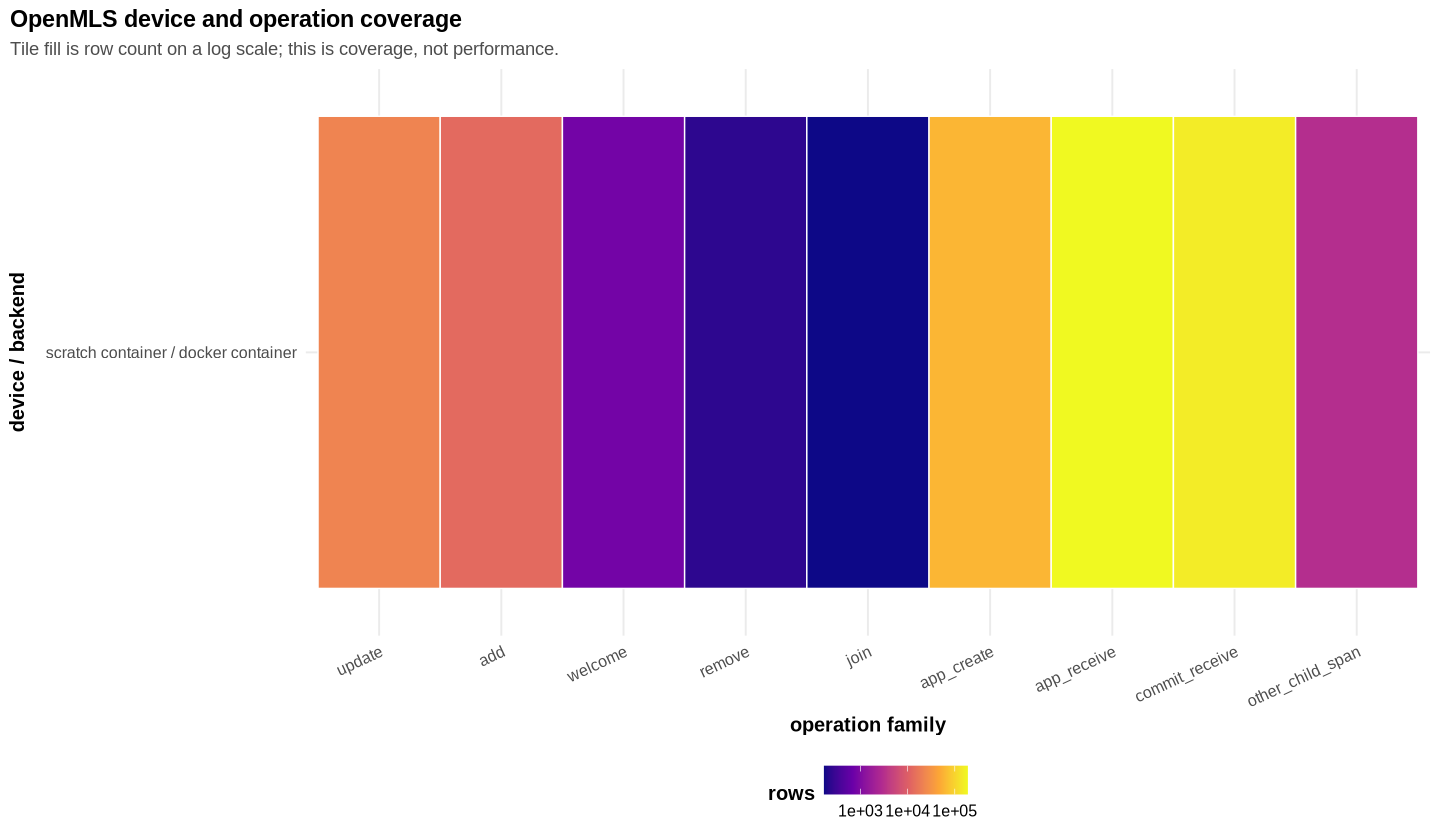


## plot_device_slowdown_vs_container
Skipped: requires both container baseline rows and external-device rows


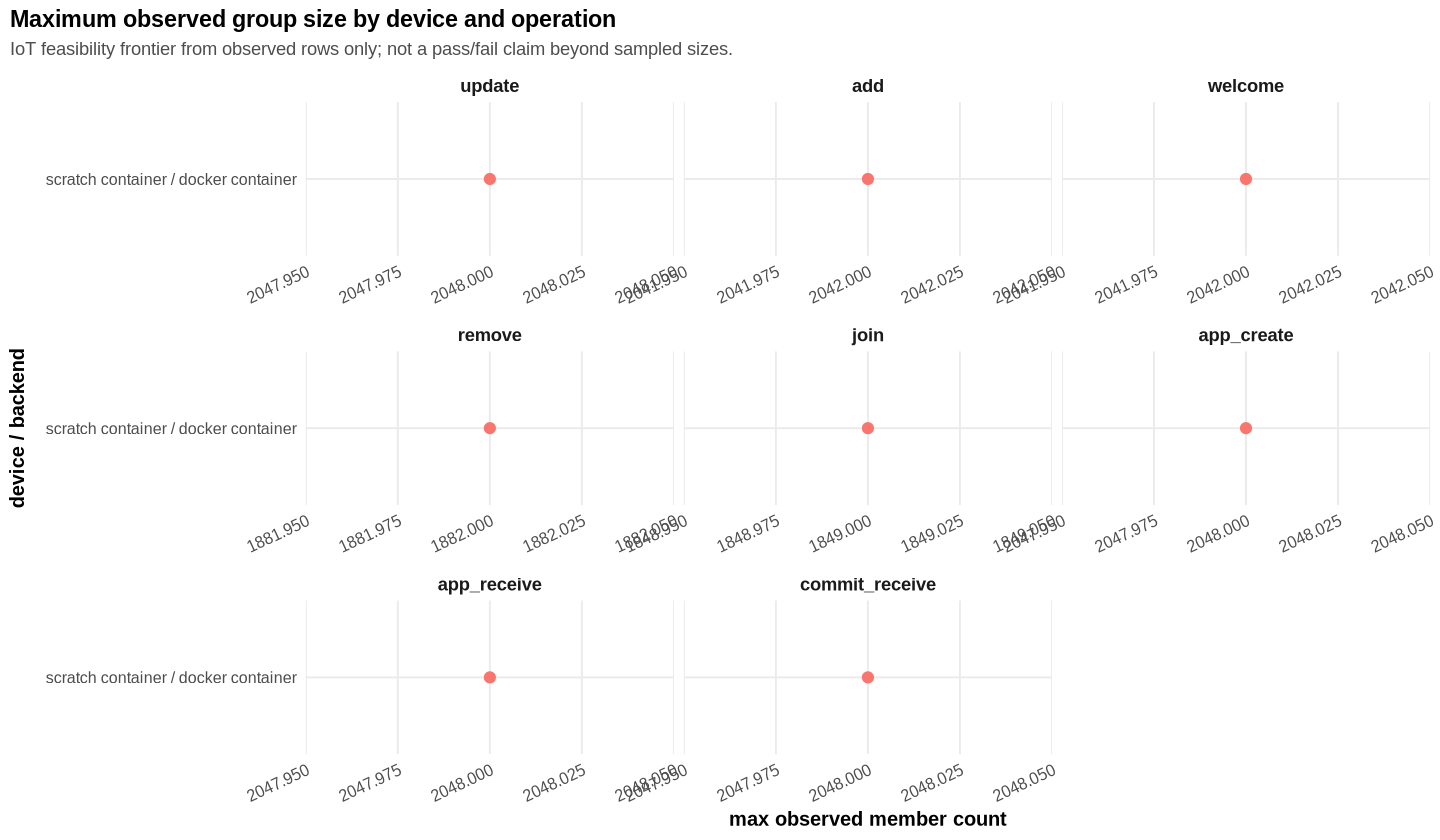

In [6]:
for (name in c(
  "plot_device_operation_coverage",
  "plot_max_group_size_by_device_operation",
  "plot_device_slowdown_vs_container"
)) show_v5_plot(name)

## B. RFC 9420 Structural Sanity


## plot_update_direct_path_scaling



## plot_update_hpke_identity


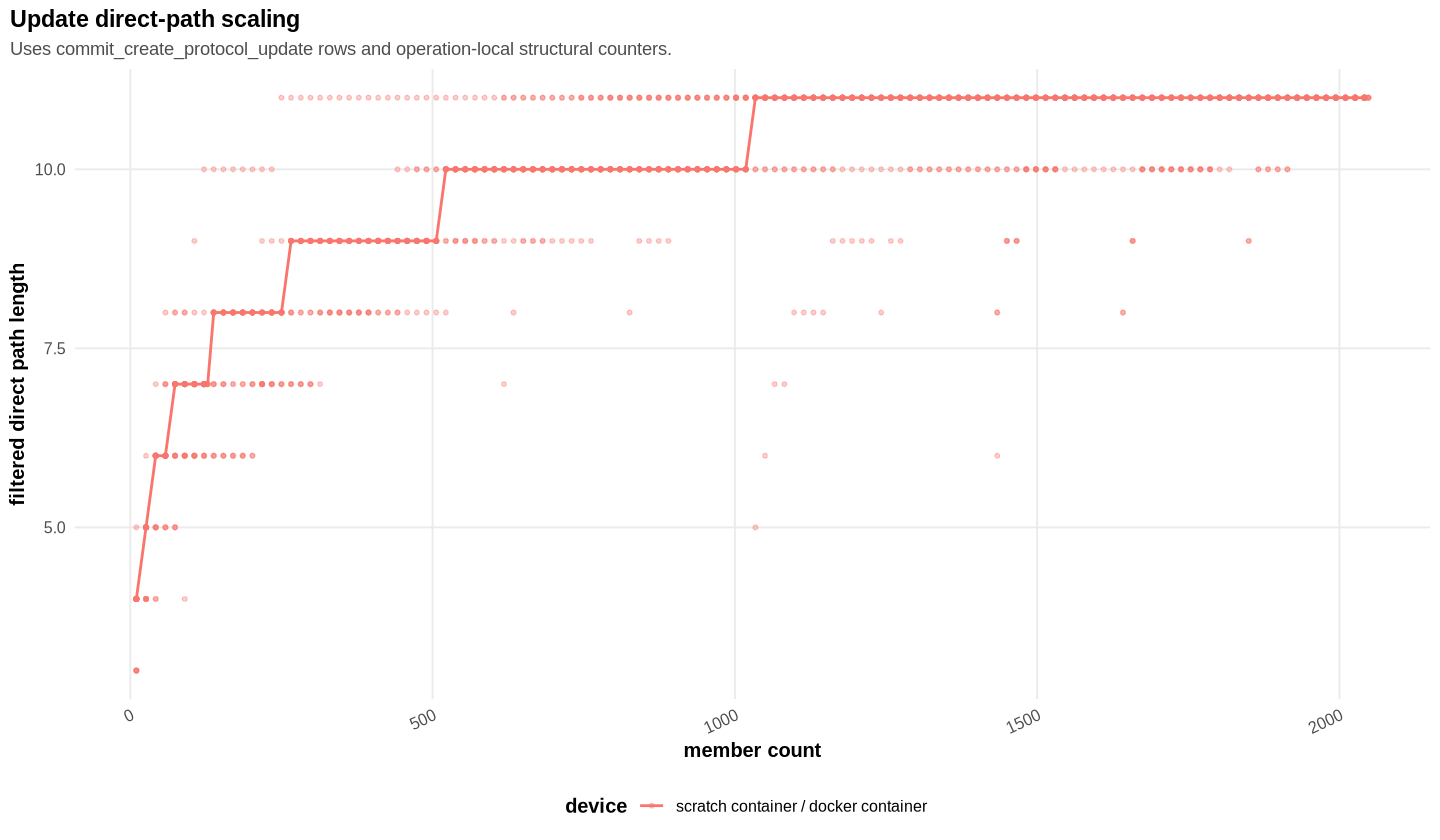


## plot_update_path_nodes_identity


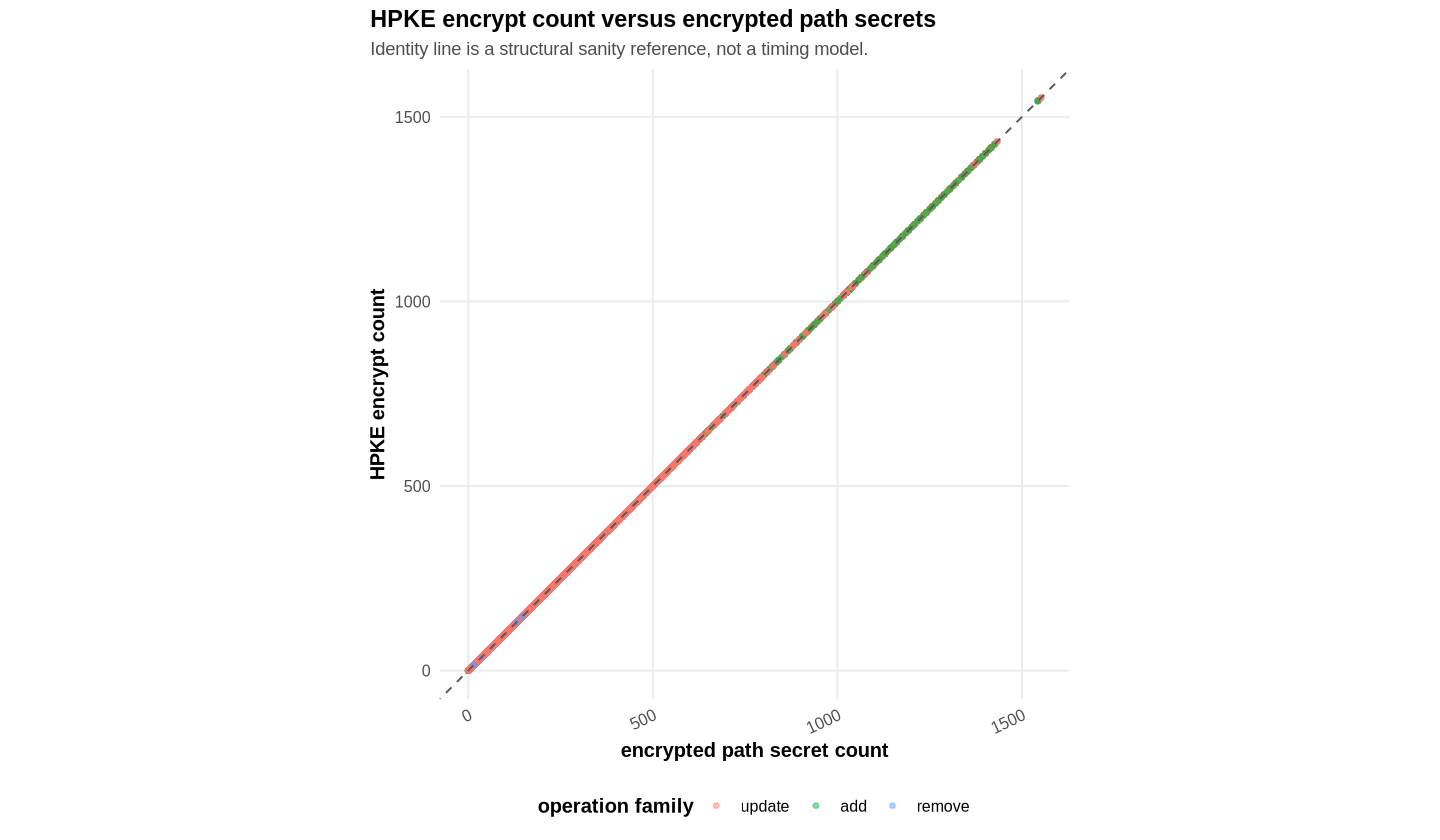


## plot_welcome_size_by_recipient_count


`geom_smooth()` using formula = 'y ~ x'


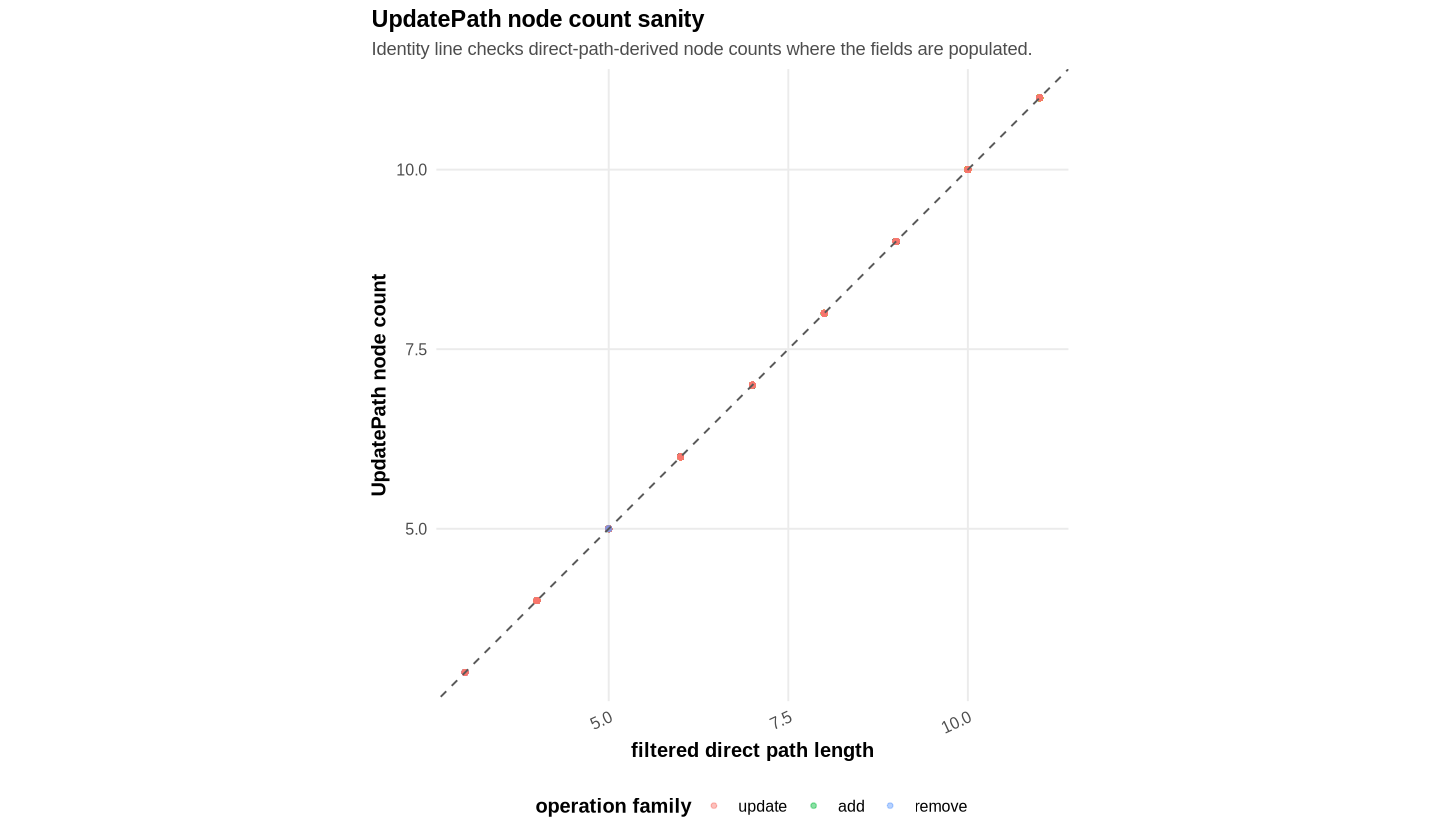


## plot_ratchet_tree_bytes_by_tree_size


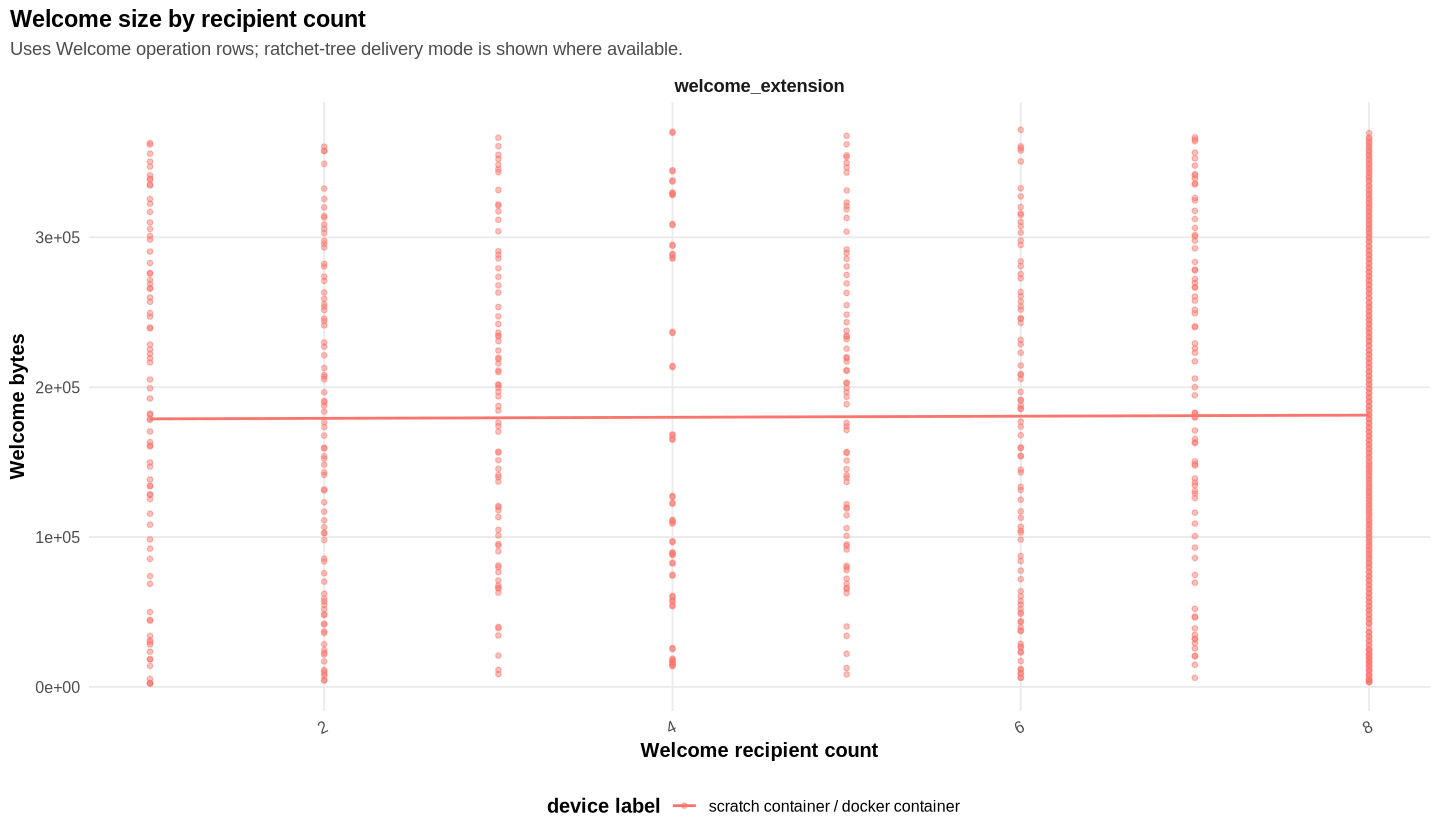


## plot_ciphertext_vs_plaintext


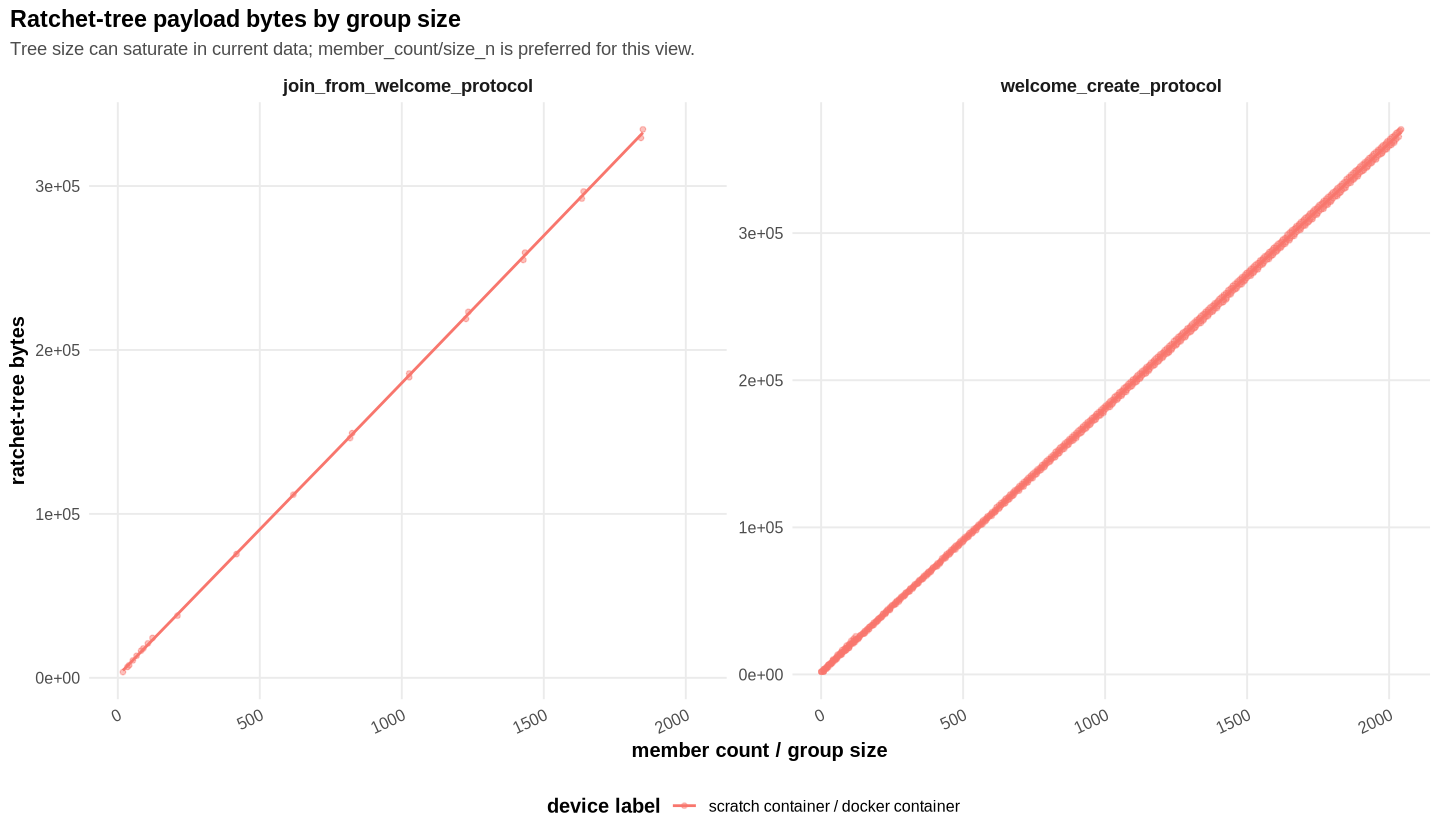

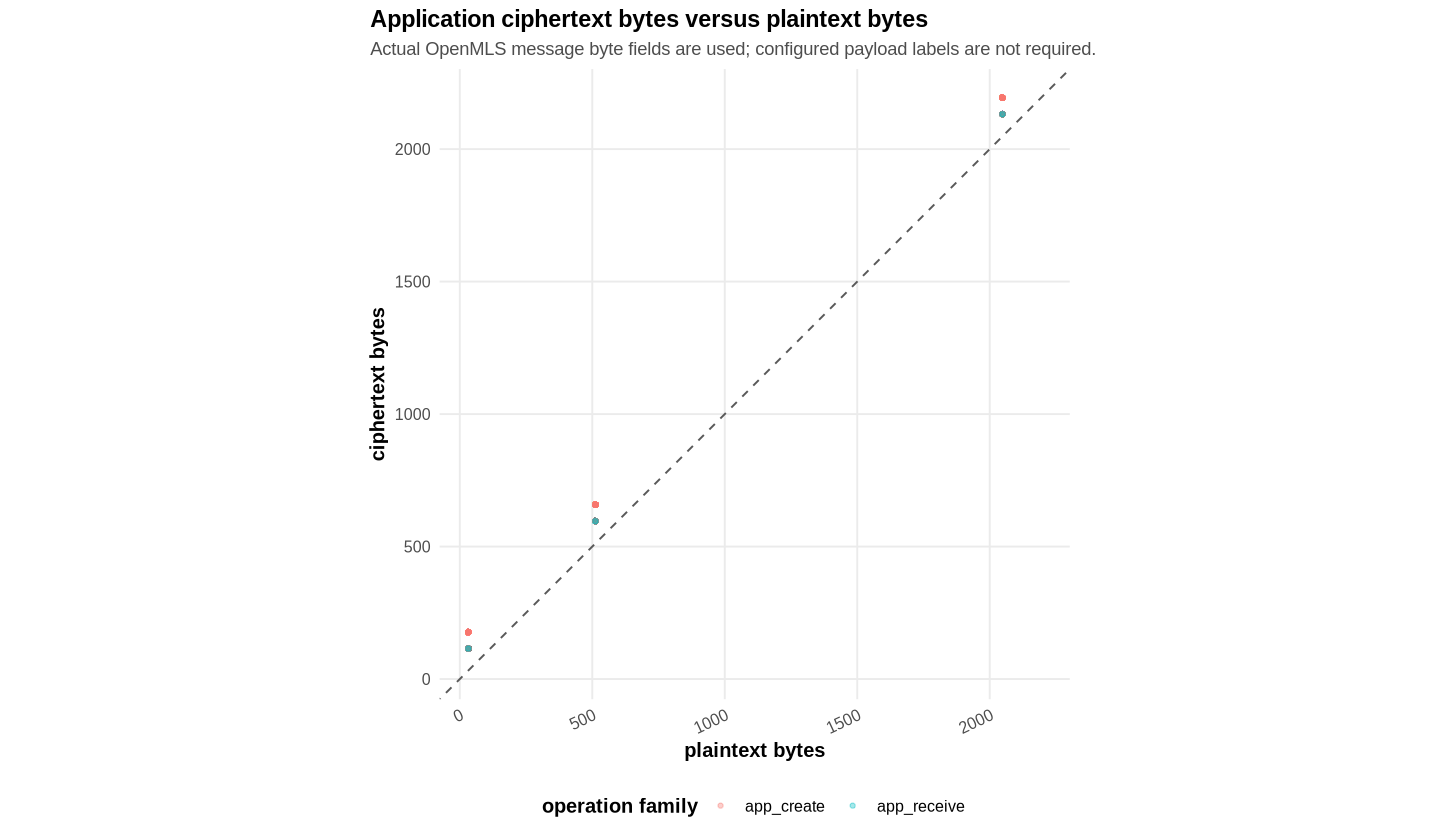

In [7]:
for (name in c(
  "plot_update_direct_path_scaling",
  "plot_update_hpke_identity",
  "plot_update_path_nodes_identity",
  "plot_welcome_size_by_recipient_count",
  "plot_ratchet_tree_bytes_by_tree_size",
  "plot_ciphertext_vs_plaintext"
)) show_v5_plot(name)

## C. SelfUpdate / Update


## plot_update_wall_time_loess



## plot_update_alloc_loess


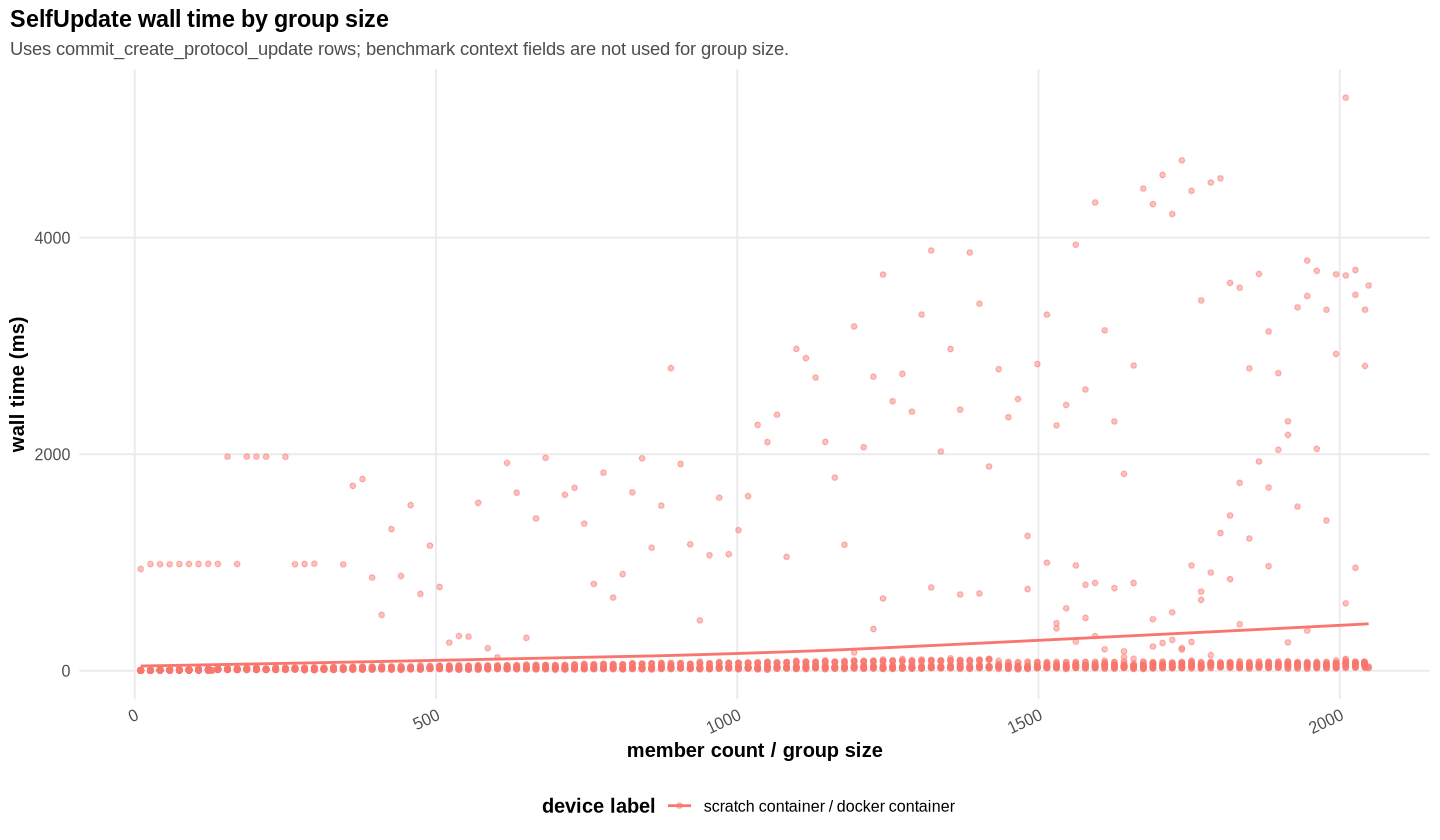


## plot_update_child_span_decomposition


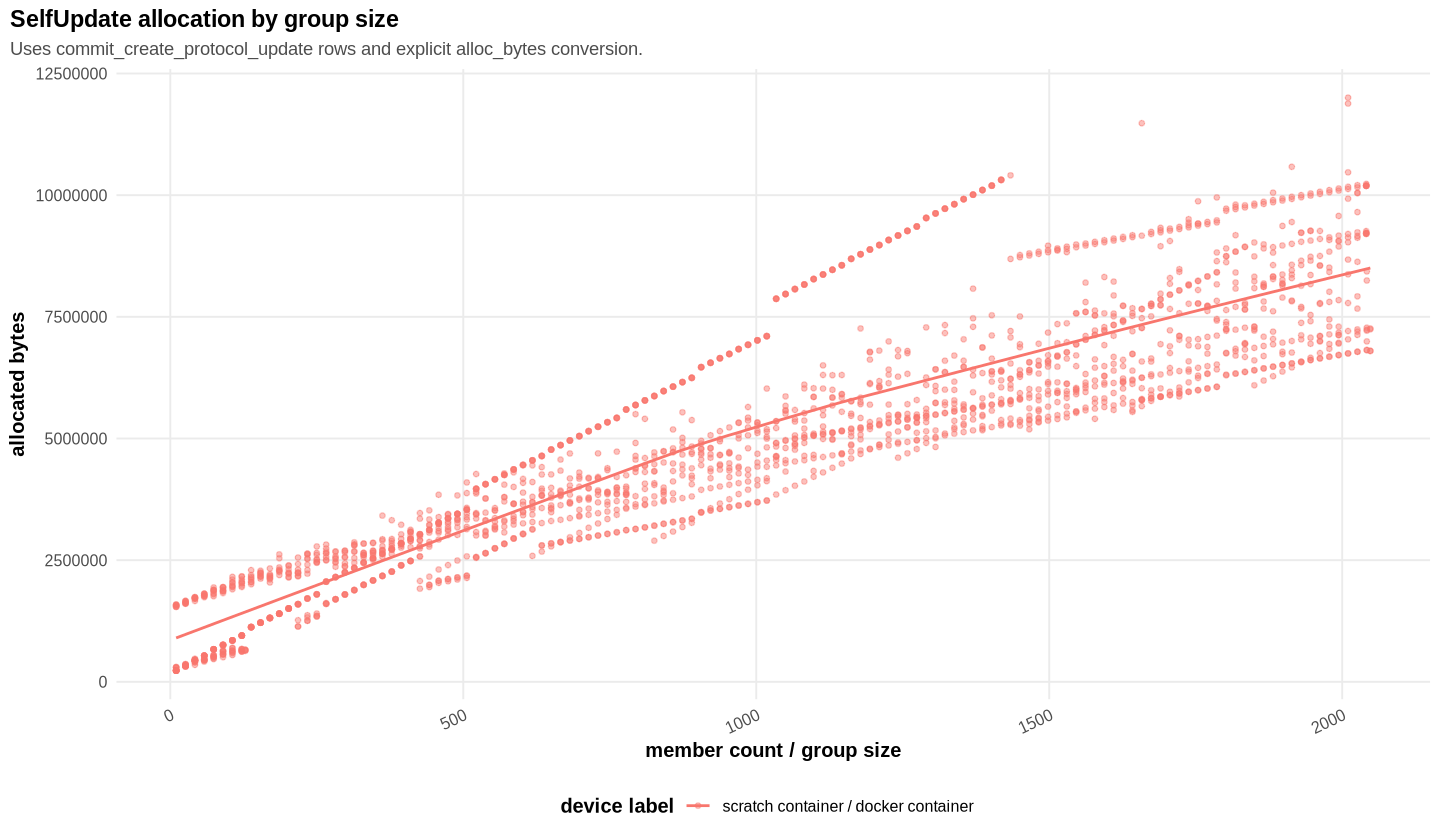


## plot_update_gam_surface


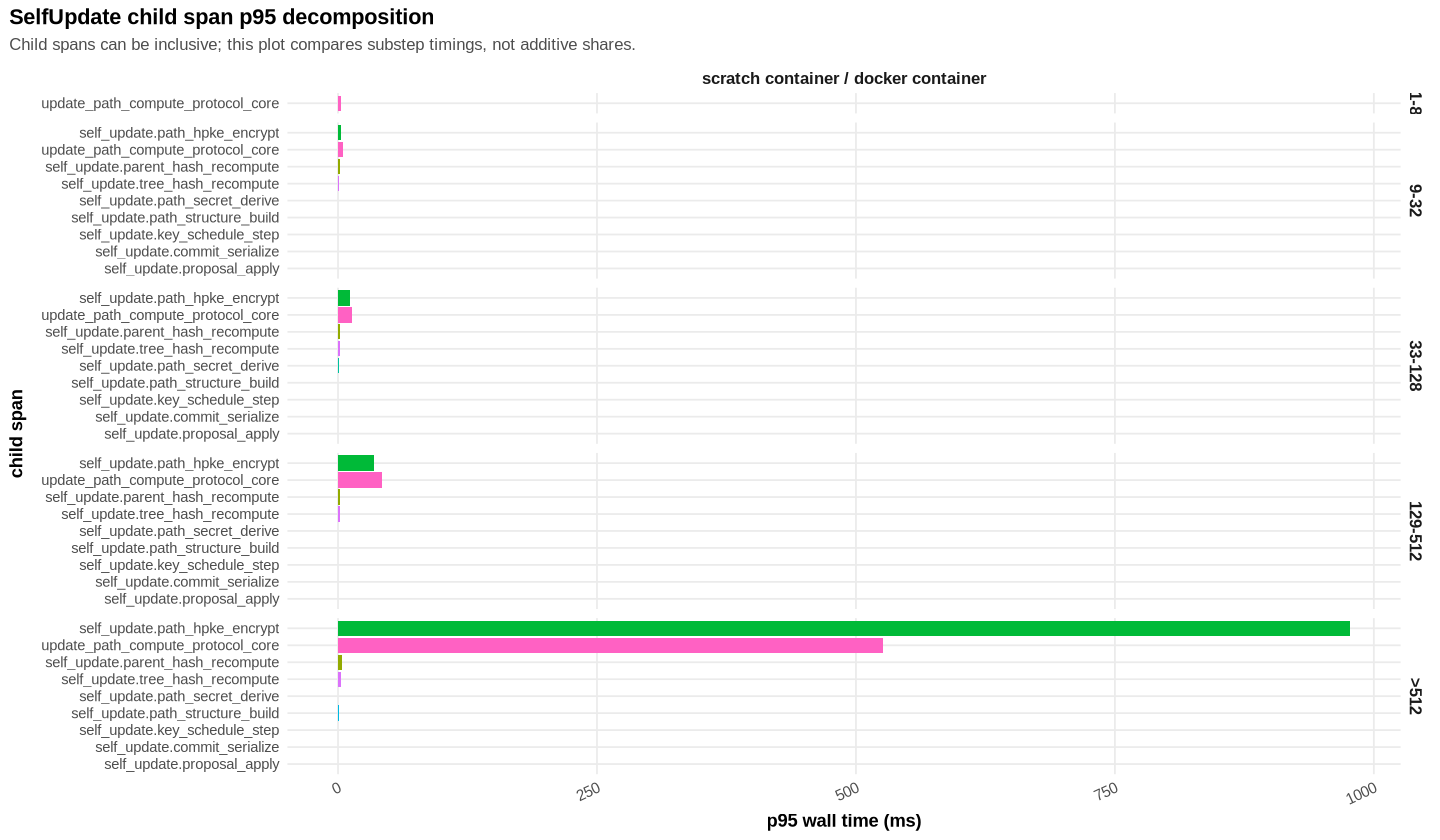

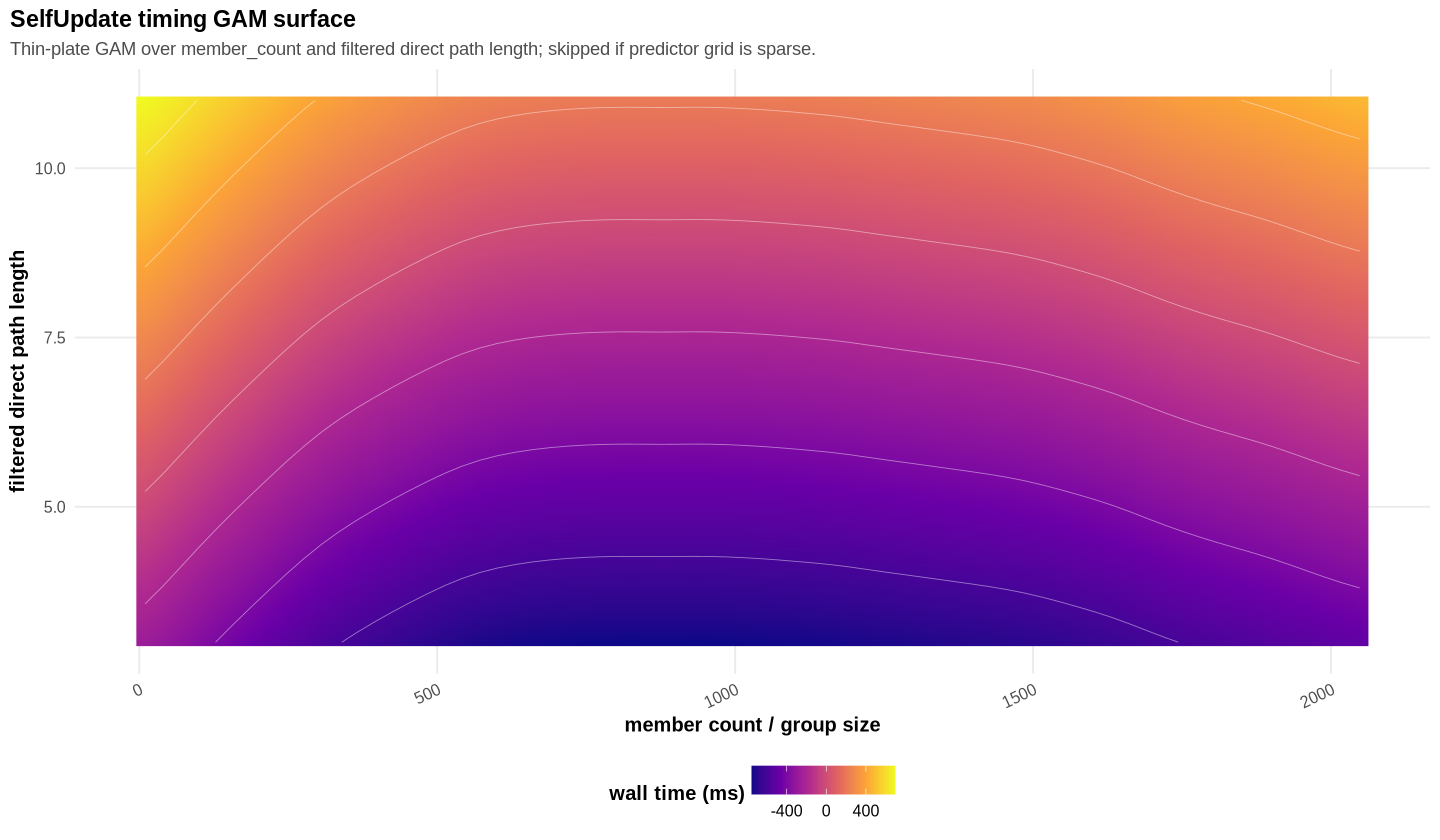

In [8]:
for (name in c(
  "plot_update_wall_time_loess",
  "plot_update_alloc_loess",
  "plot_update_child_span_decomposition",
  "plot_update_gam_surface"
)) show_v5_plot(name)

## D. Add + Welcome


## plot_add_wall_time_loess



## plot_add_welcome_split


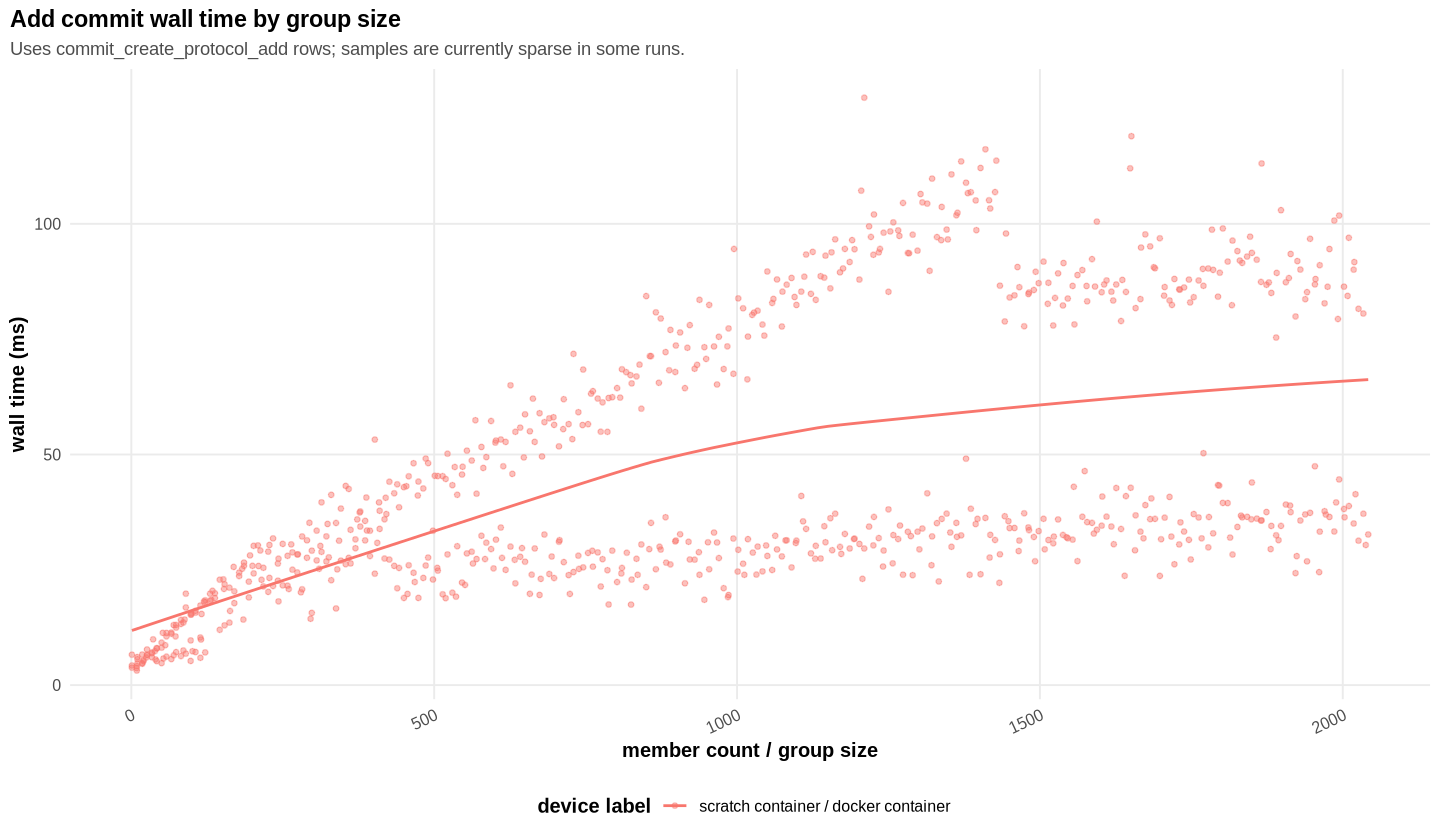


## plot_welcome_secret_count_identity


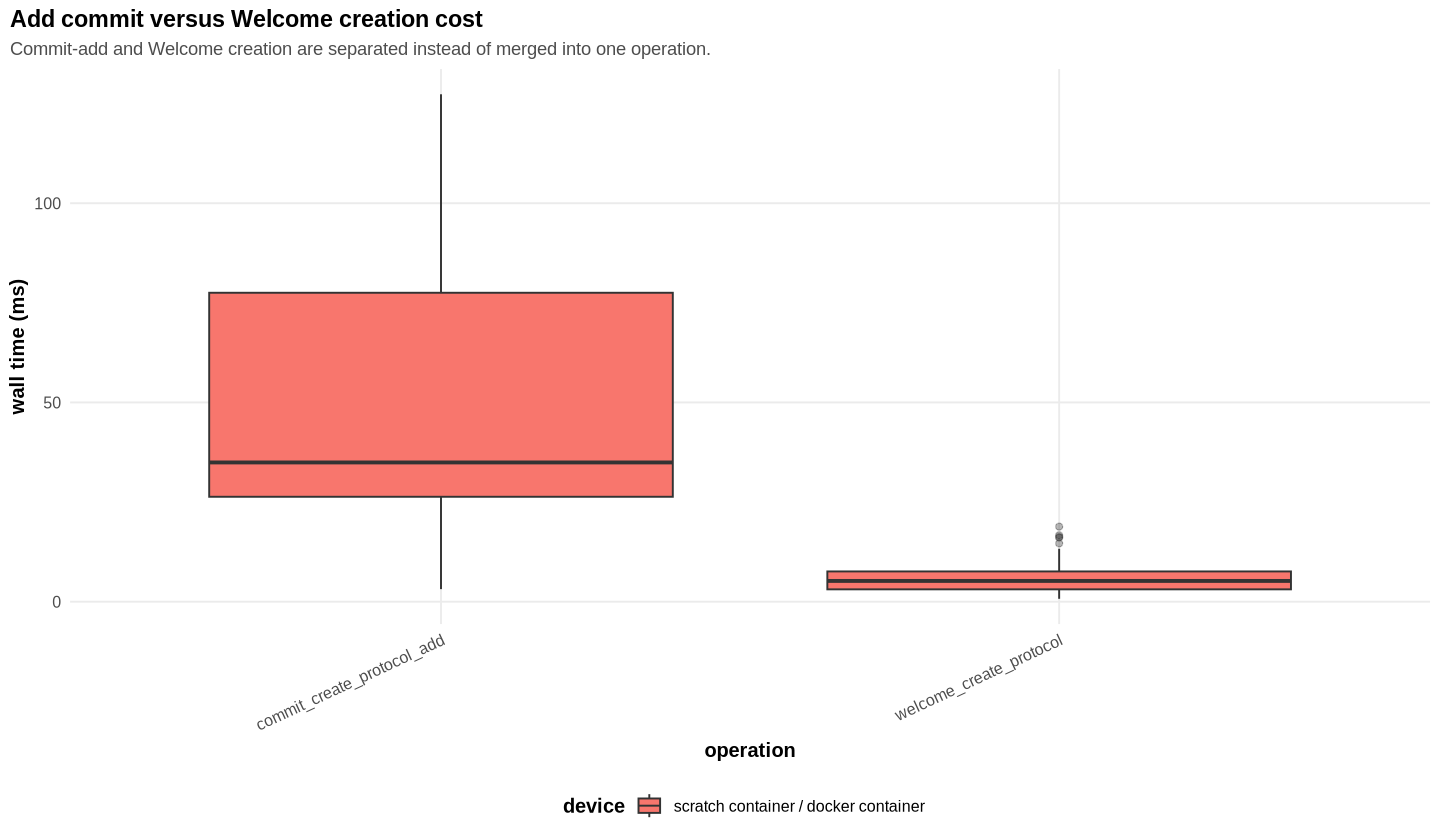


## plot_welcome_bytes_by_device


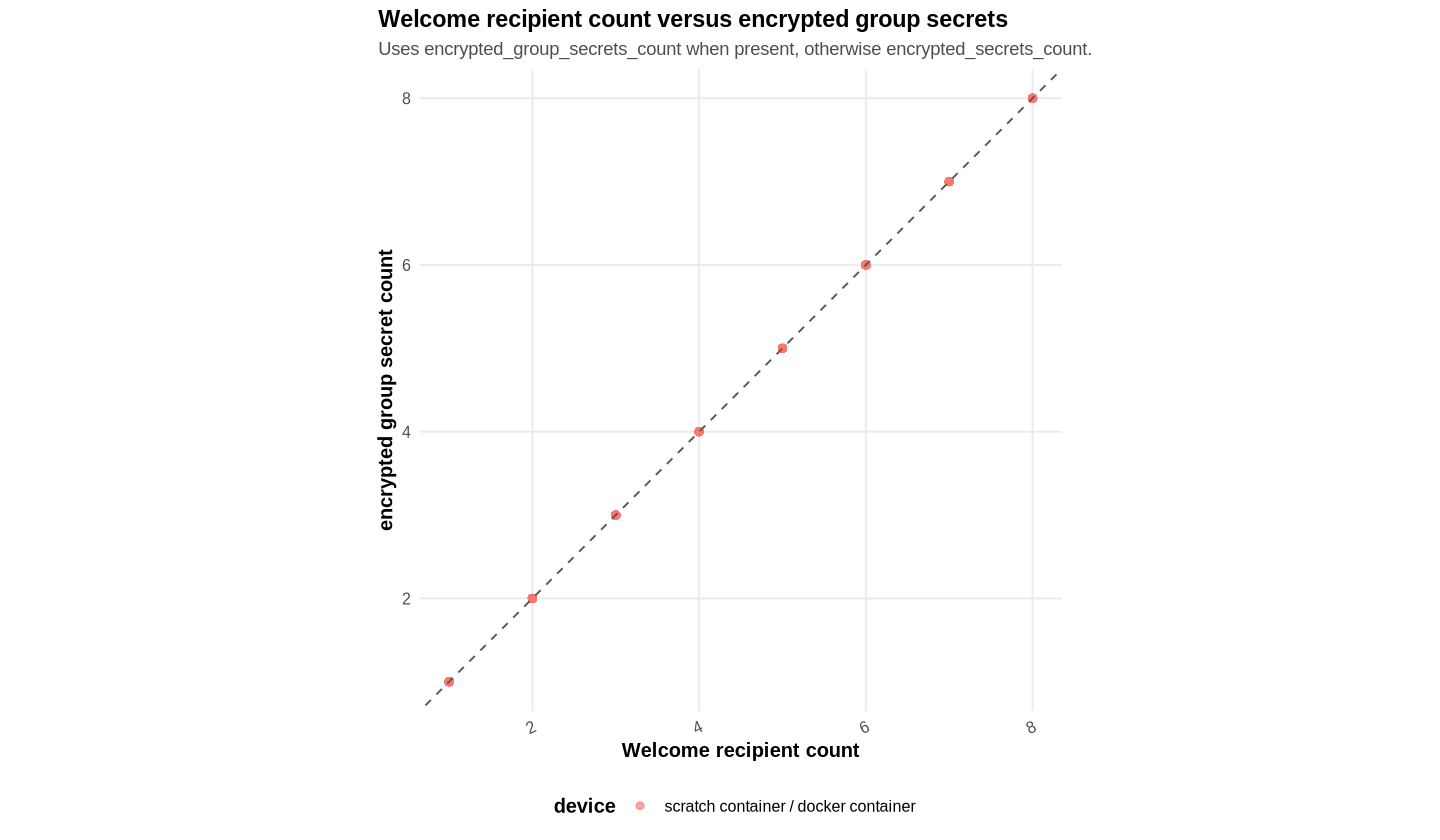

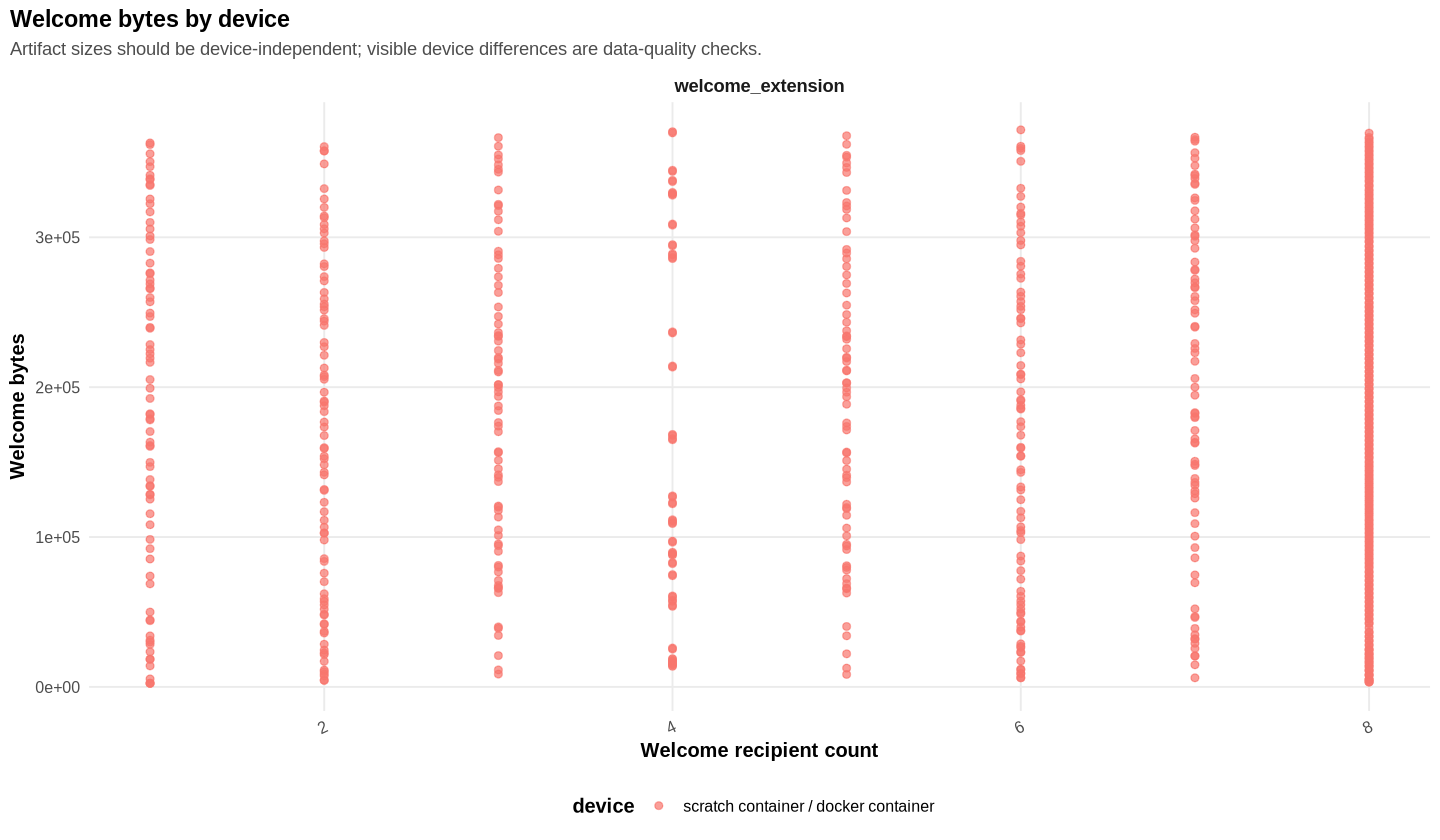

In [9]:
for (name in c(
  "plot_add_wall_time_loess",
  "plot_add_welcome_split",
  "plot_welcome_secret_count_identity",
  "plot_welcome_bytes_by_device"
)) show_v5_plot(name)

## E. Remove


## plot_remove_tree_before_after



## plot_remove_truncation_duration
Skipped: remove rows contain only one truncation state; boxplot would imply unsupported comparison

## plot_remove_truncated_levels_distribution


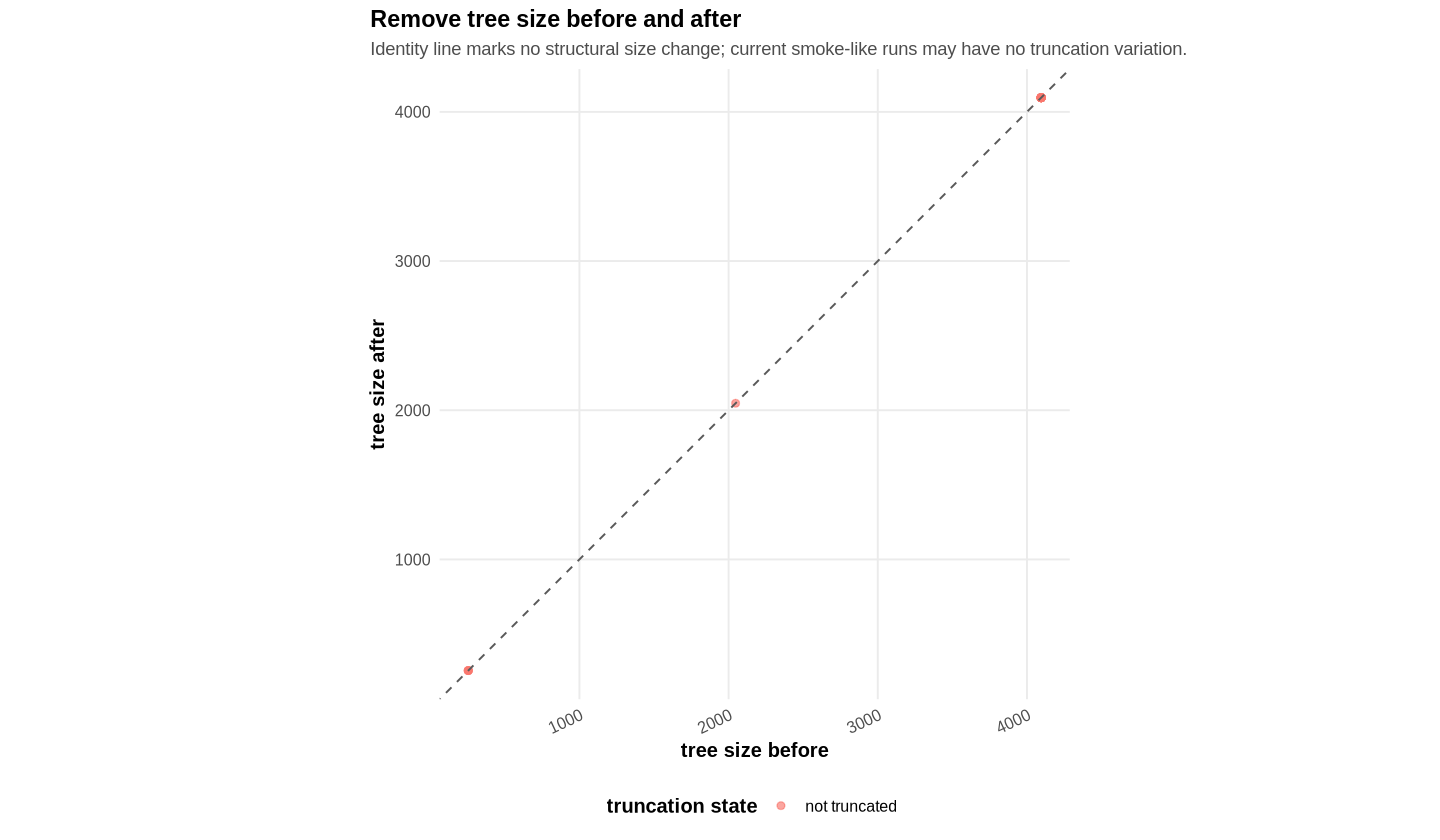


## plot_remove_wall_time


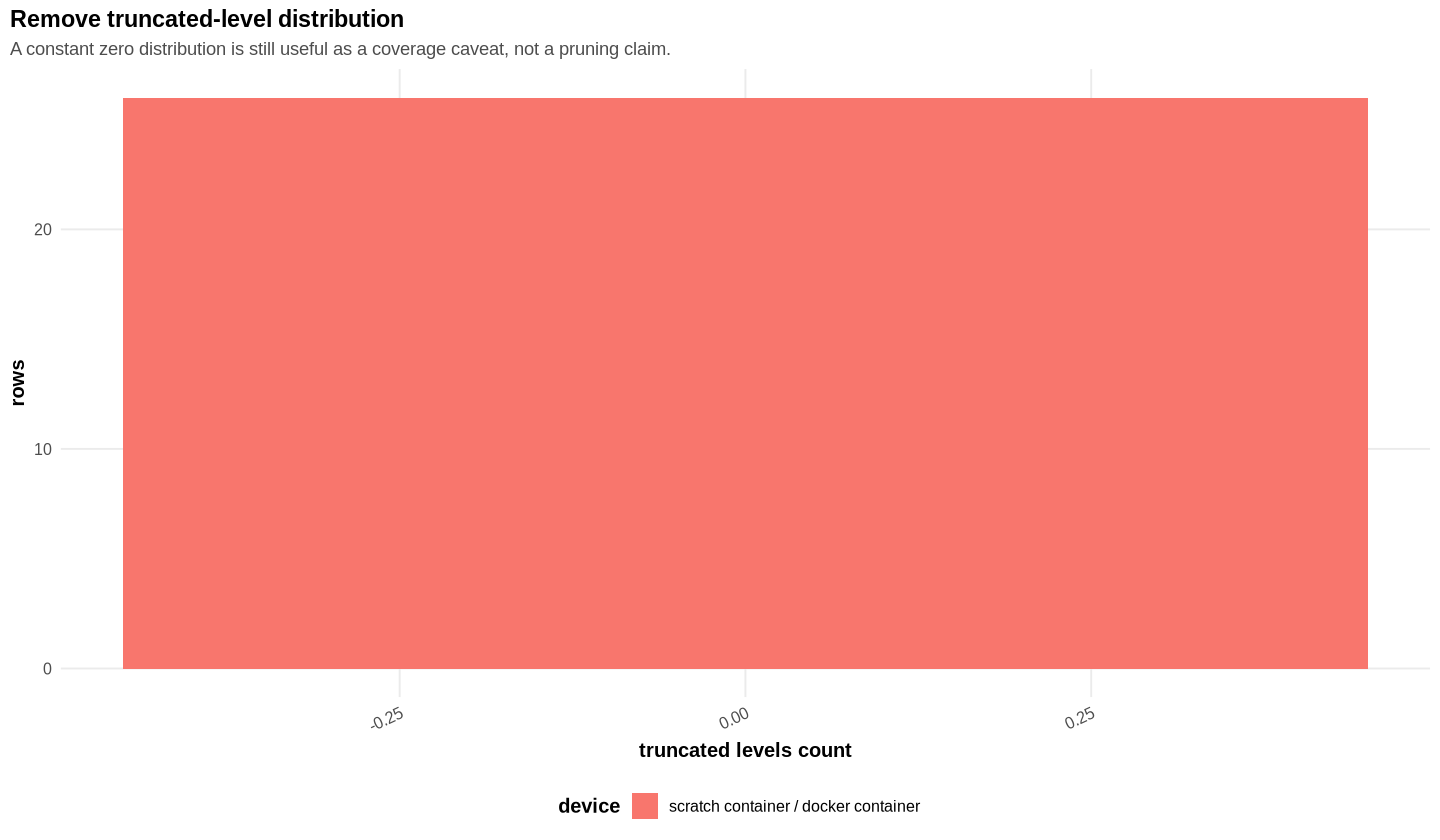

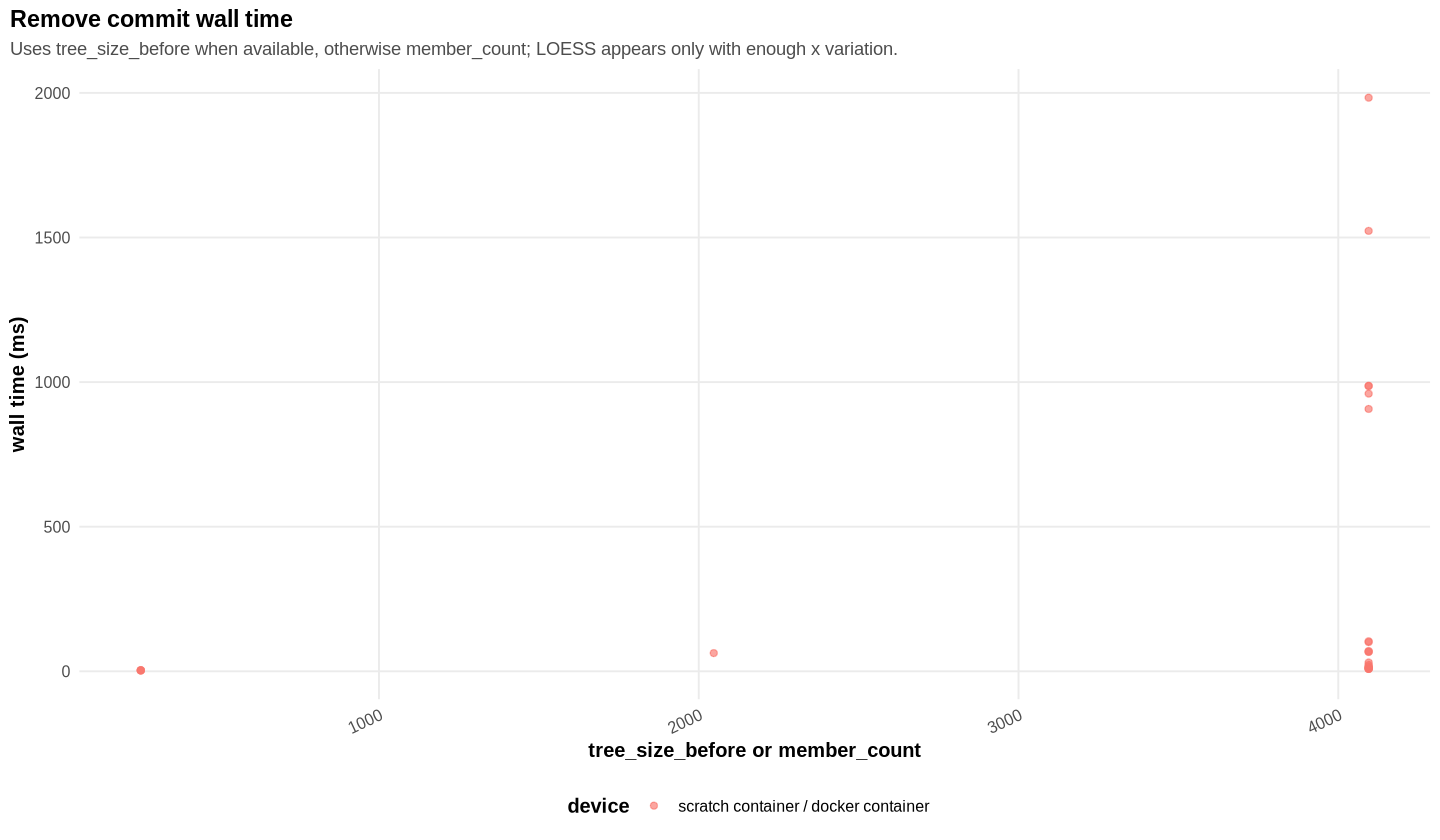

In [10]:
for (name in c(
  "plot_remove_tree_before_after",
  "plot_remove_truncation_duration",
  "plot_remove_truncated_levels_distribution",
  "plot_remove_wall_time"
)) show_v5_plot(name)

## F. JoinFromWelcome


## plot_join_wall_vs_ratchet_tree_bytes



## plot_join_payload_components


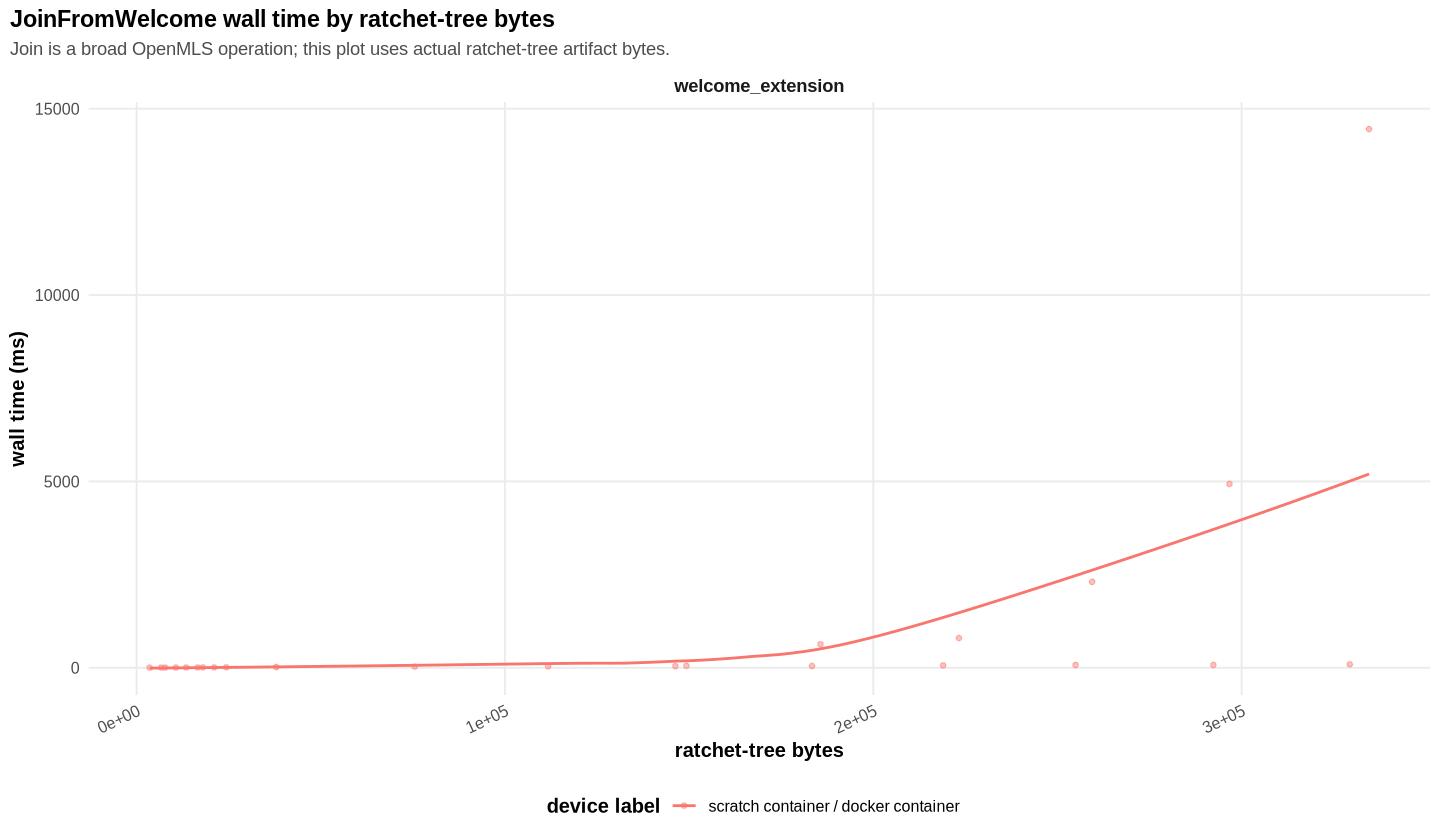


## plot_join_delivery_mode_boxplot
Skipped: only one ratchet_tree_delivery_mode is present; delivery-mode comparison skipped

## plot_join_gam_surface
Skipped: JoinFromWelcome timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors


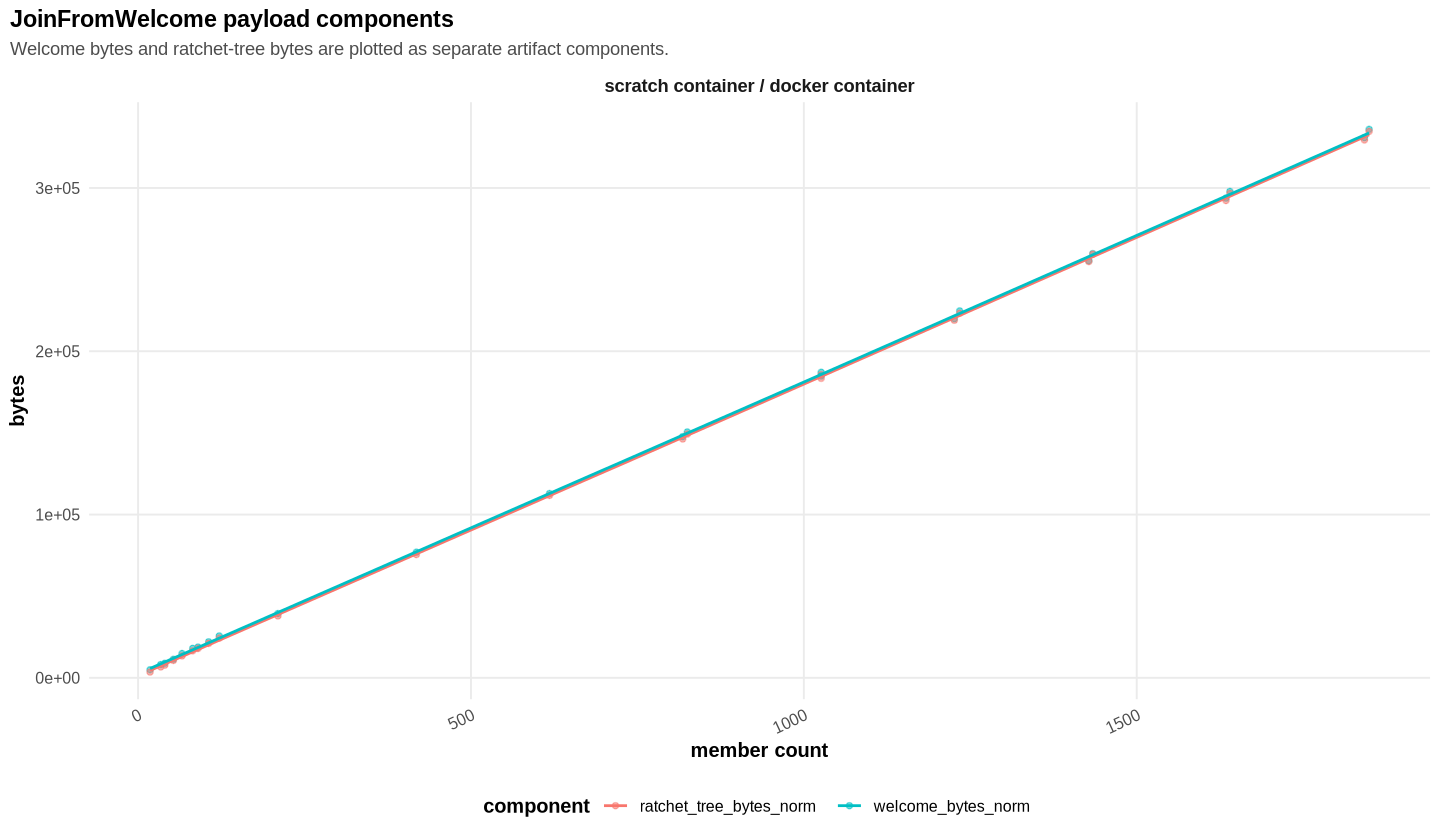

In [11]:
for (name in c(
  "plot_join_wall_vs_ratchet_tree_bytes",
  "plot_join_payload_components",
  "plot_join_delivery_mode_boxplot",
  "plot_join_gam_surface"
)) show_v5_plot(name)

## G. ApplicationMessageCreate


## plot_app_create_wall_vs_plaintext



## plot_app_create_payload_boxplot


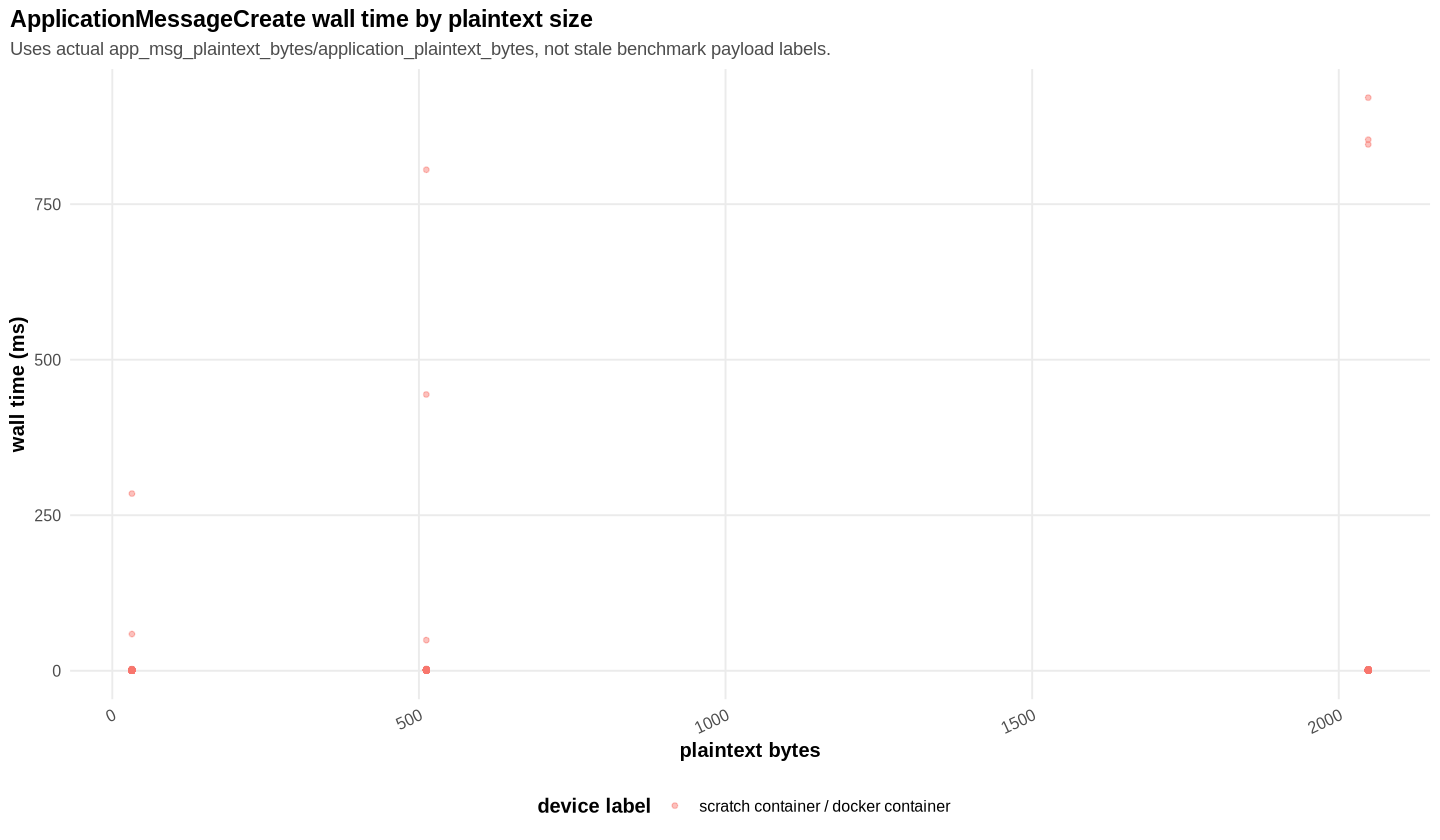


## plot_app_create_generation_effect


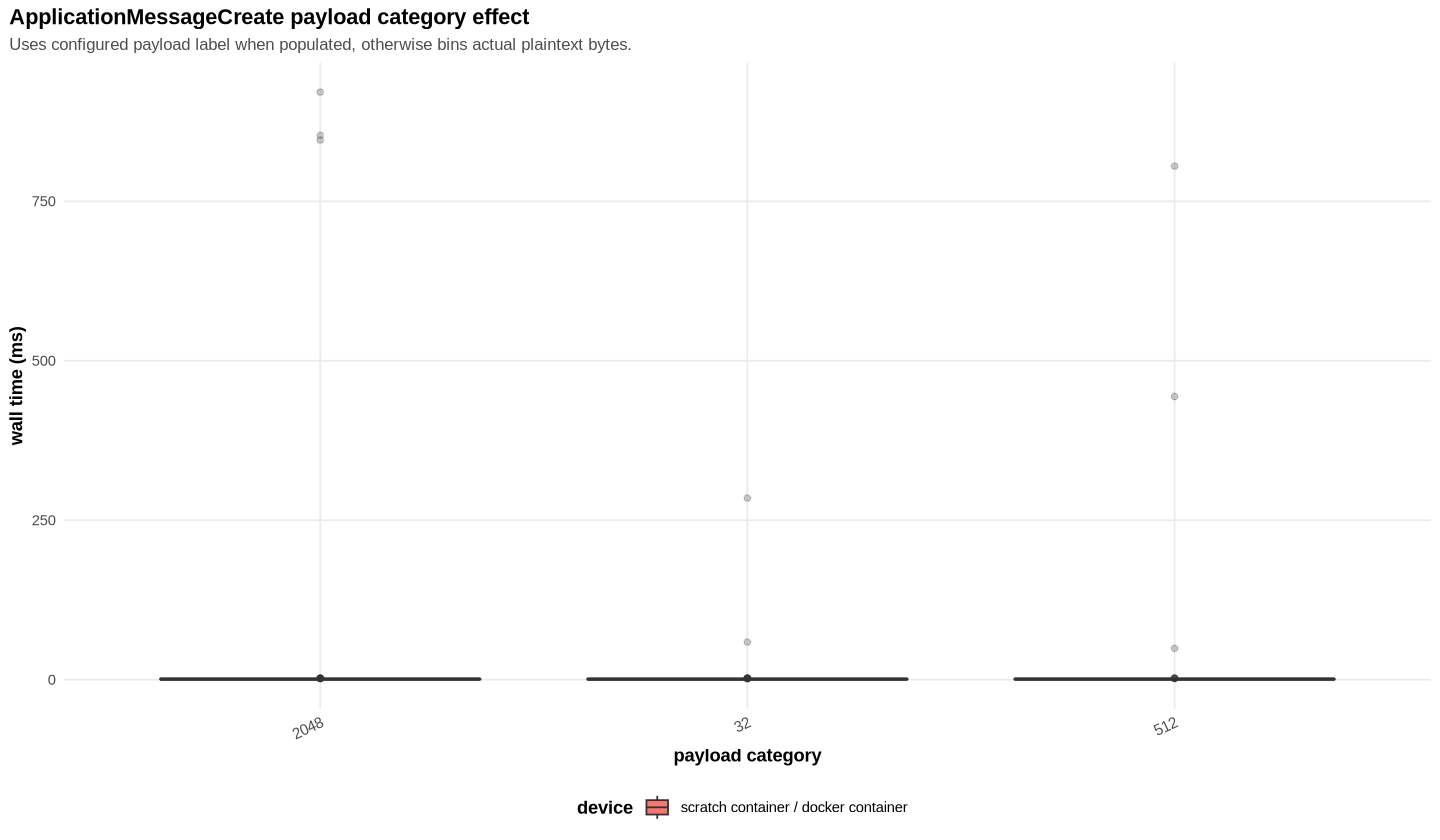


## plot_app_create_child_span_comparison


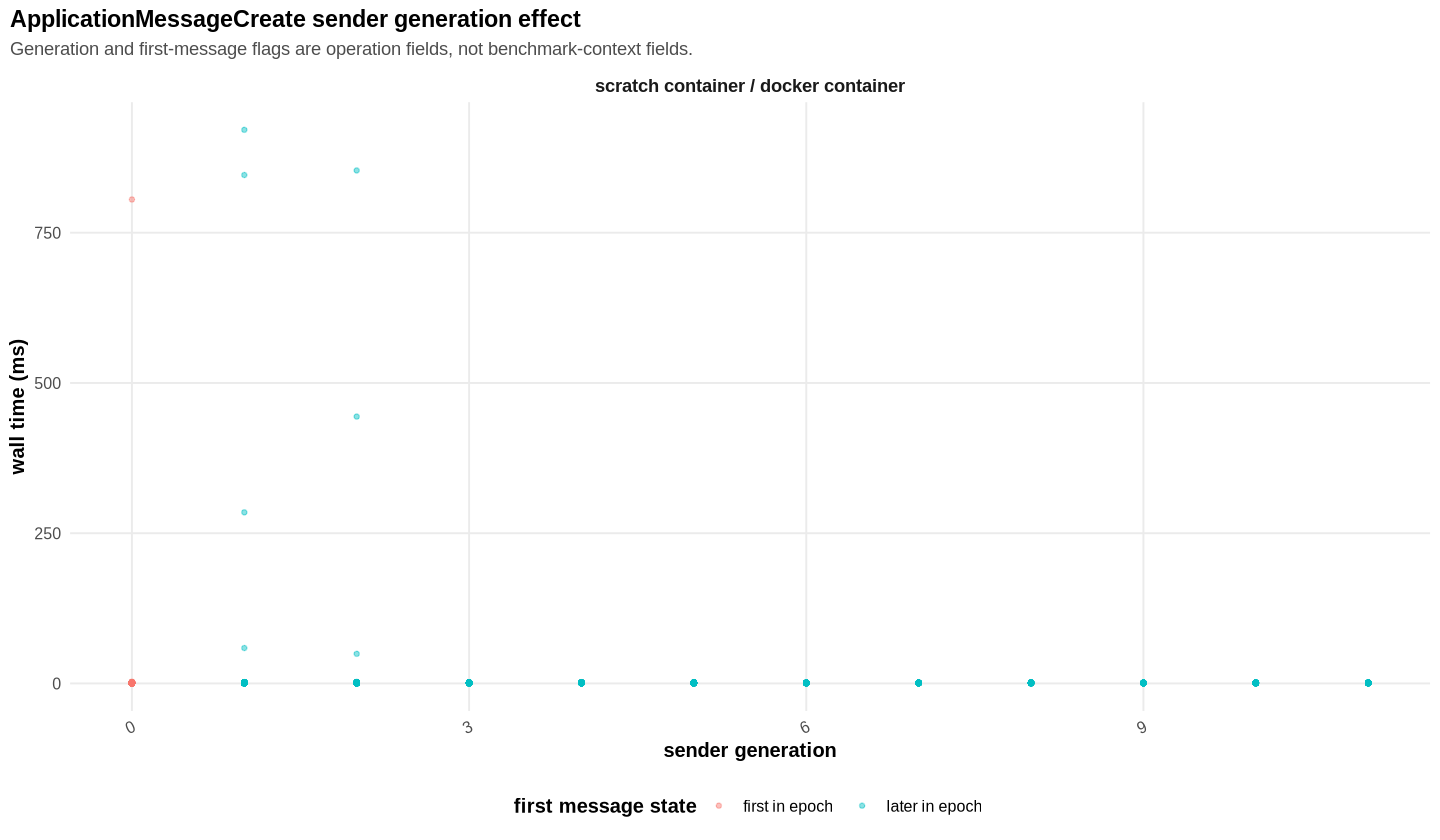


## plot_app_create_gam_surface
Skipped: ApplicationMessageCreate timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors


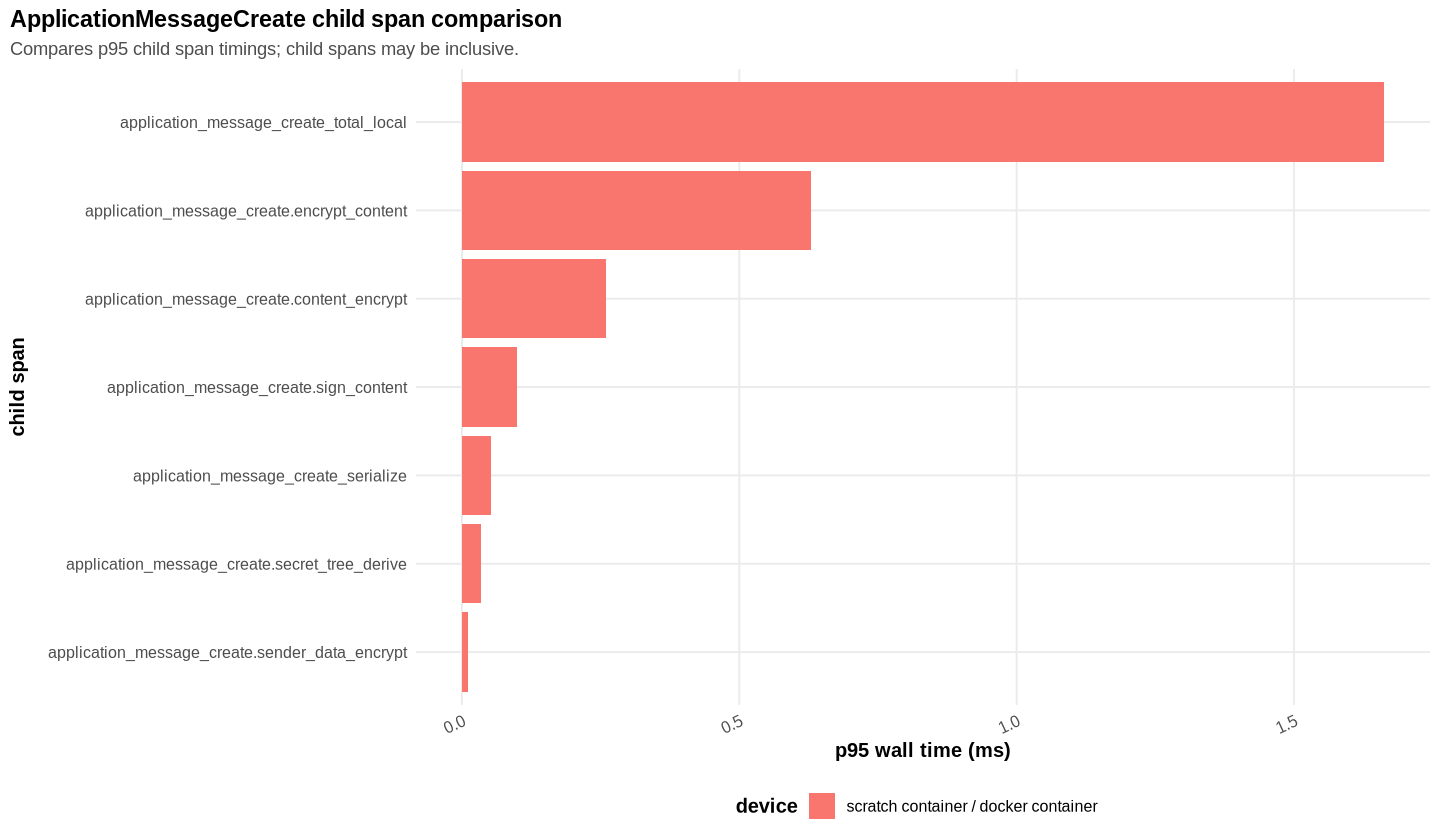

In [12]:
for (name in c(
  "plot_app_create_wall_vs_plaintext",
  "plot_app_create_payload_boxplot",
  "plot_app_create_generation_effect",
  "plot_app_create_child_span_comparison",
  "plot_app_create_gam_surface"
)) show_v5_plot(name)

## H. ApplicationMessageReceive


## plot_app_receive_wall_vs_ciphertext



## plot_app_receive_generation_gap


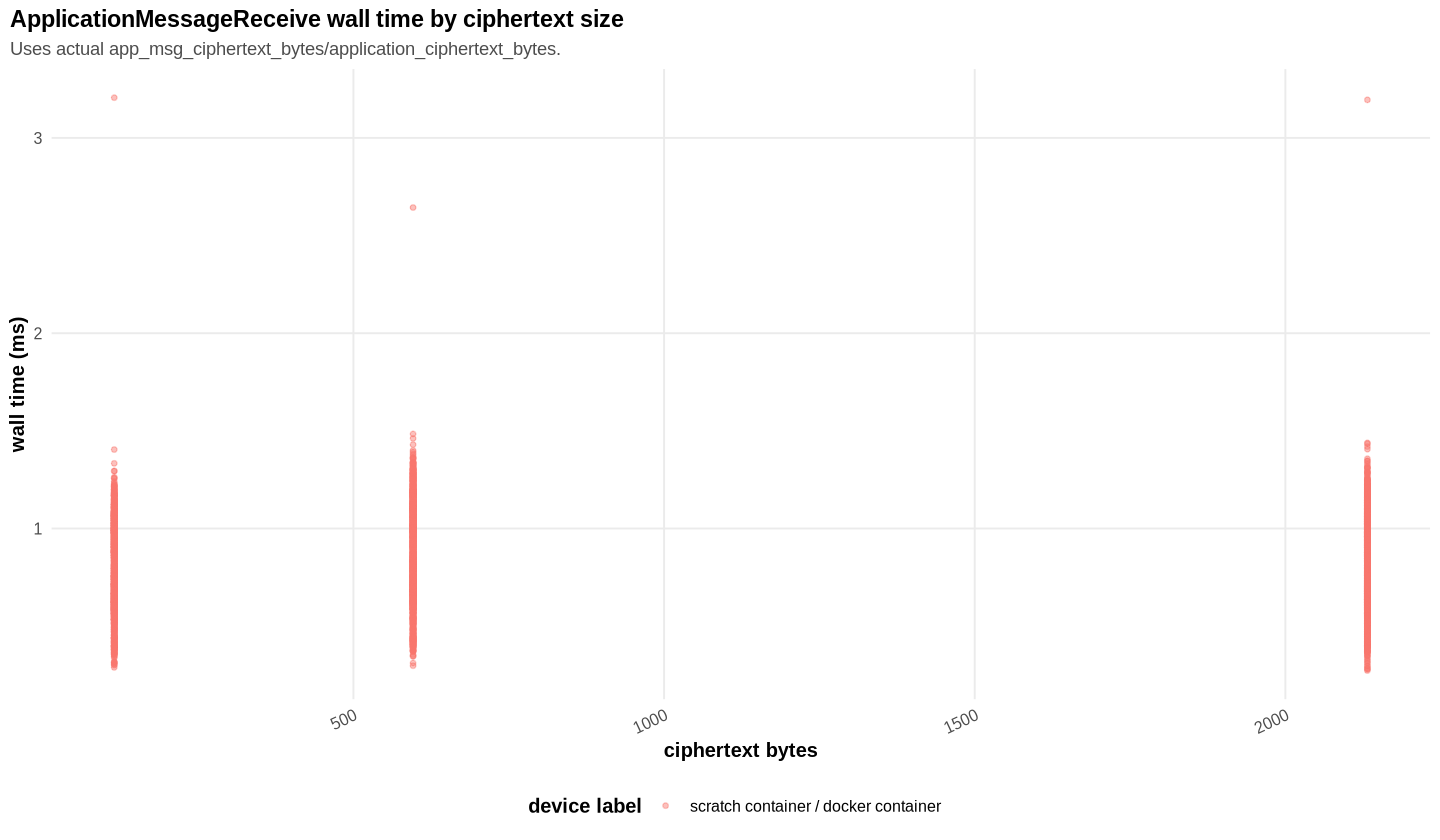


## plot_app_receive_first_receive


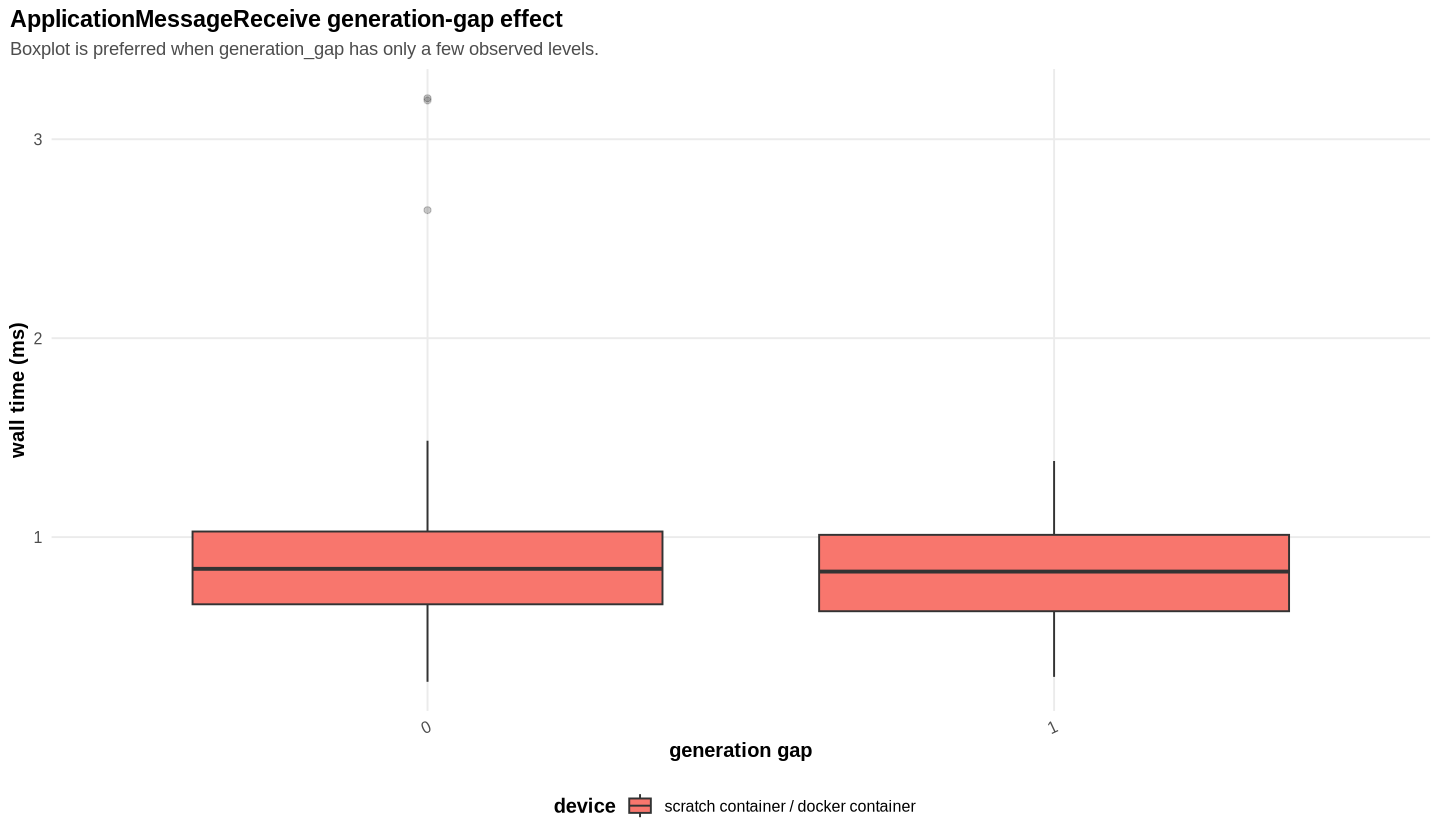


## plot_app_receive_child_span_comparison


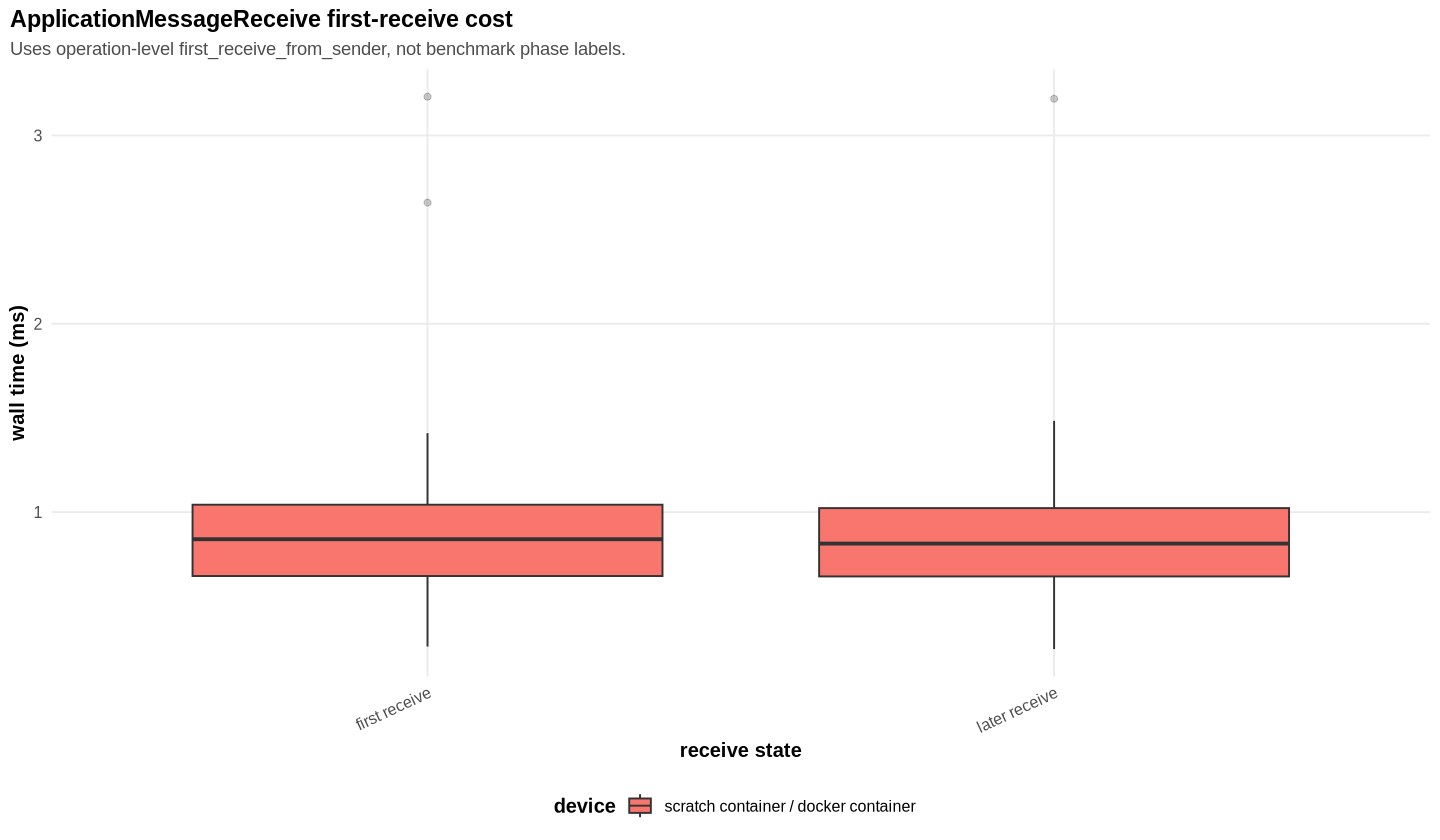


## plot_app_receive_gam_surface
Skipped: ApplicationMessageReceive timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors


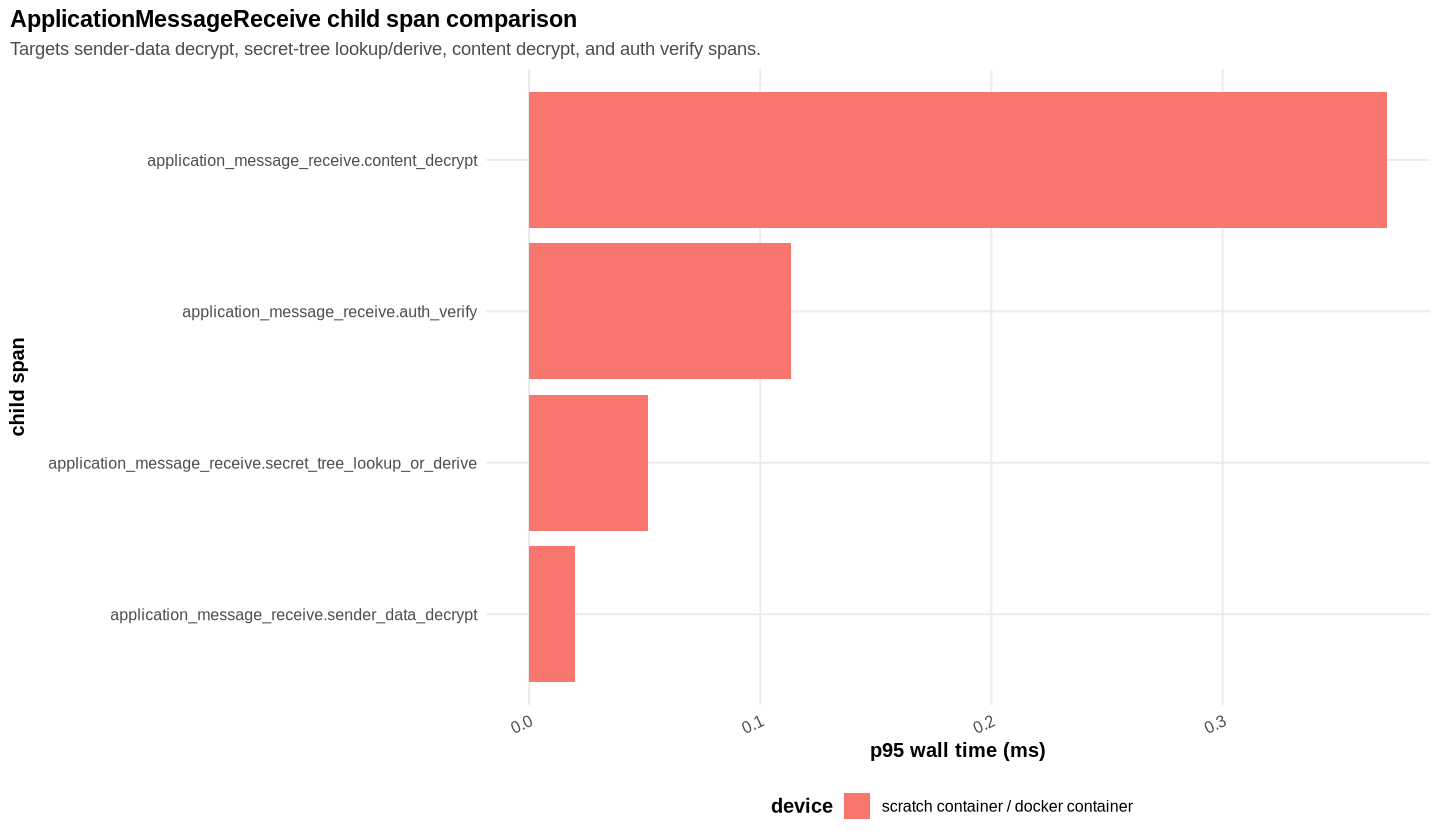

In [13]:
for (name in c(
  "plot_app_receive_wall_vs_ciphertext",
  "plot_app_receive_generation_gap",
  "plot_app_receive_first_receive",
  "plot_app_receive_child_span_comparison",
  "plot_app_receive_gam_surface"
)) show_v5_plot(name)

## I. CommitReceive


## plot_commit_receive_wall_by_member_count



## plot_commit_receive_wall_by_commit_size


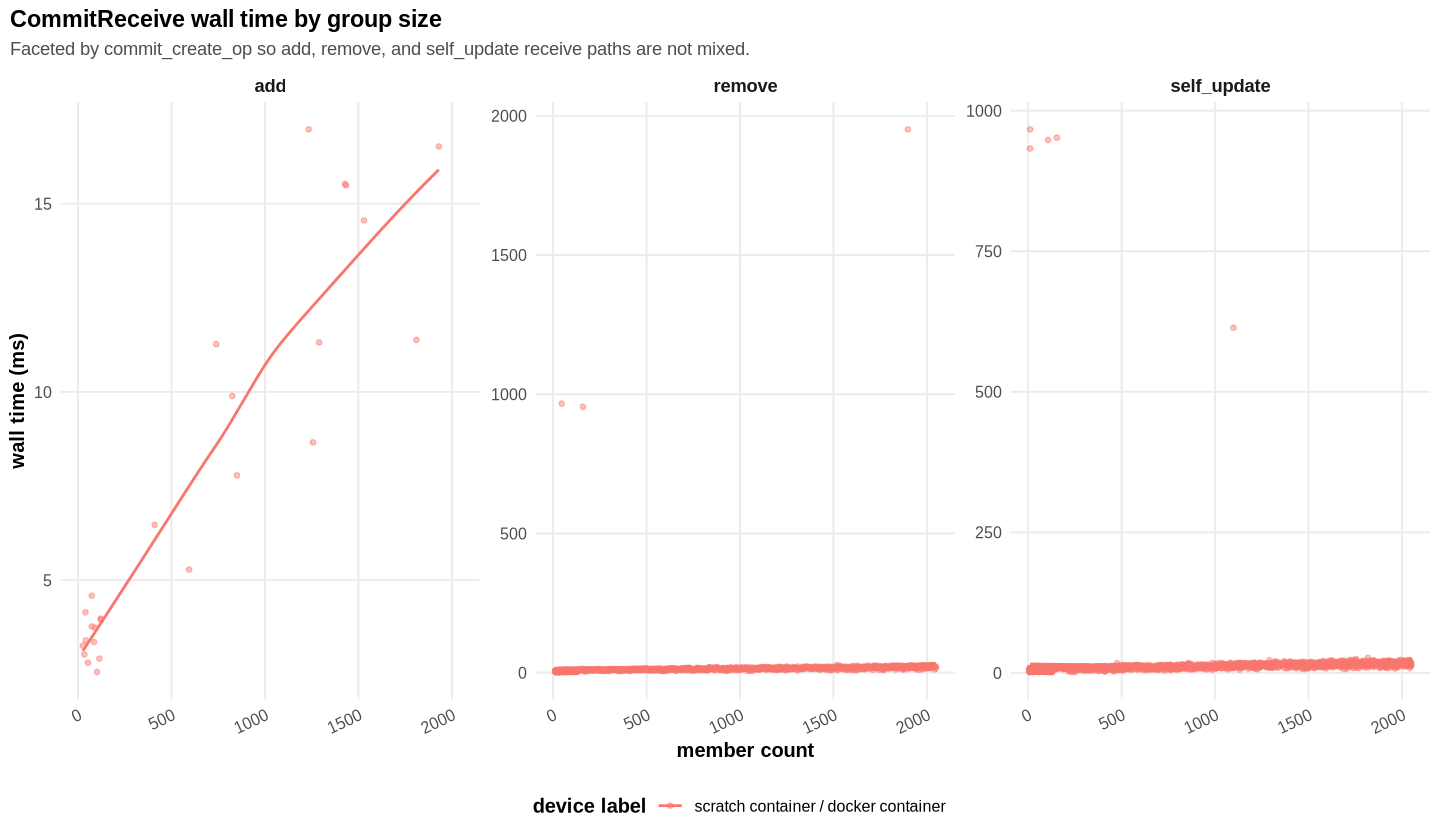


## plot_commit_receive_child_decomposition


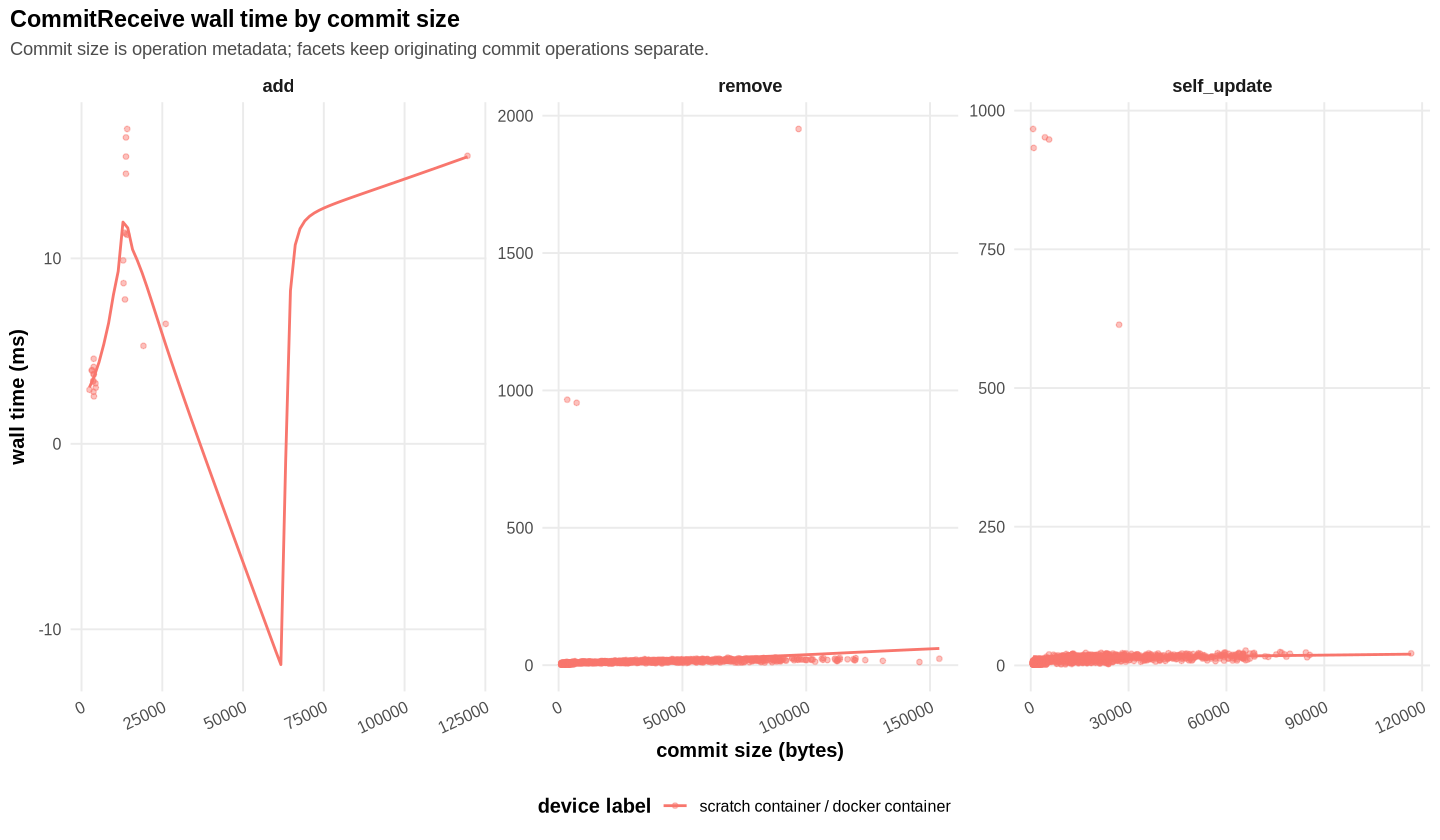


## plot_commit_receive_receiver_position


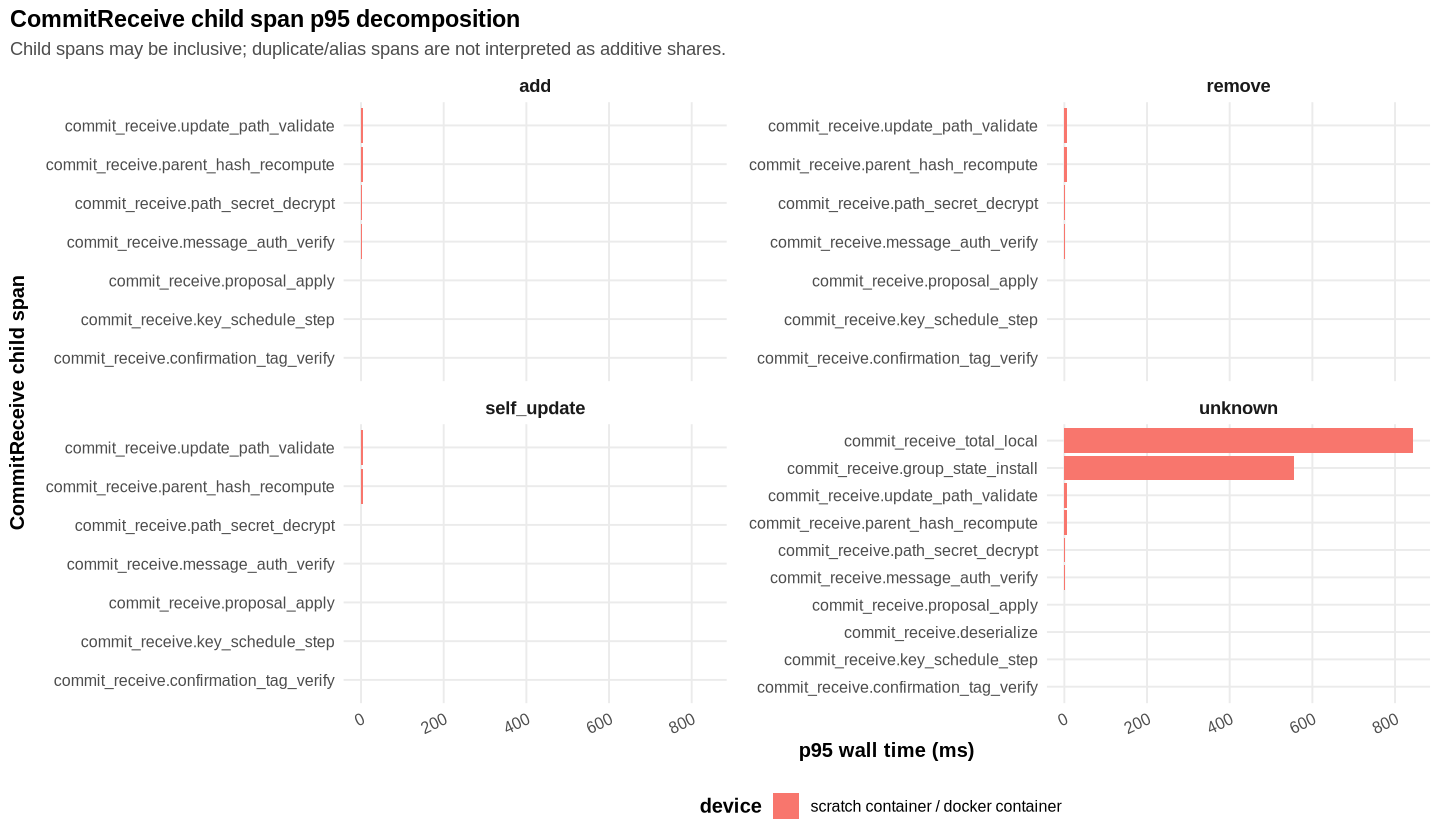


## plot_commit_receive_sampling_coverage


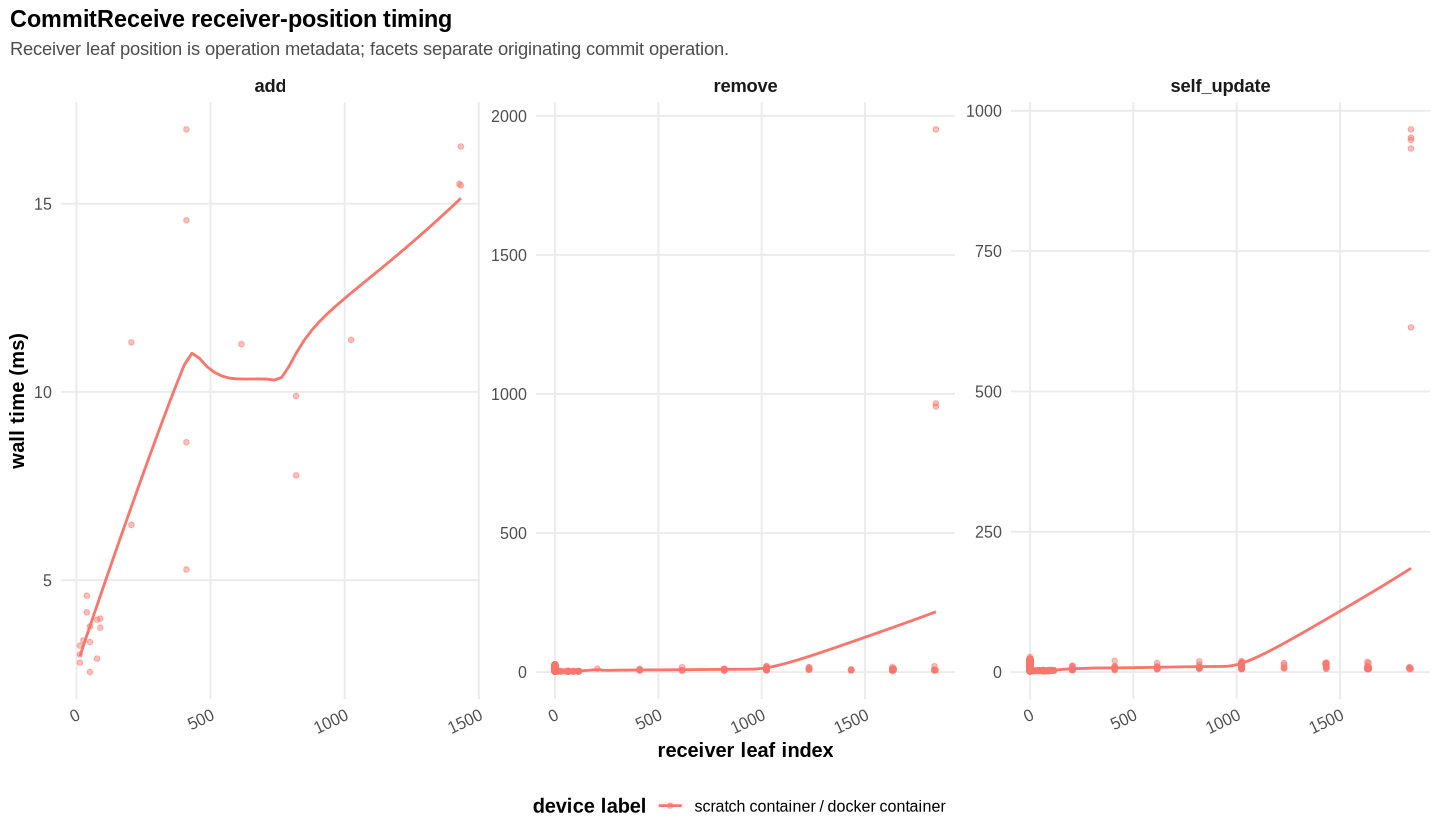


## plot_commit_receive_parent_child_consistency


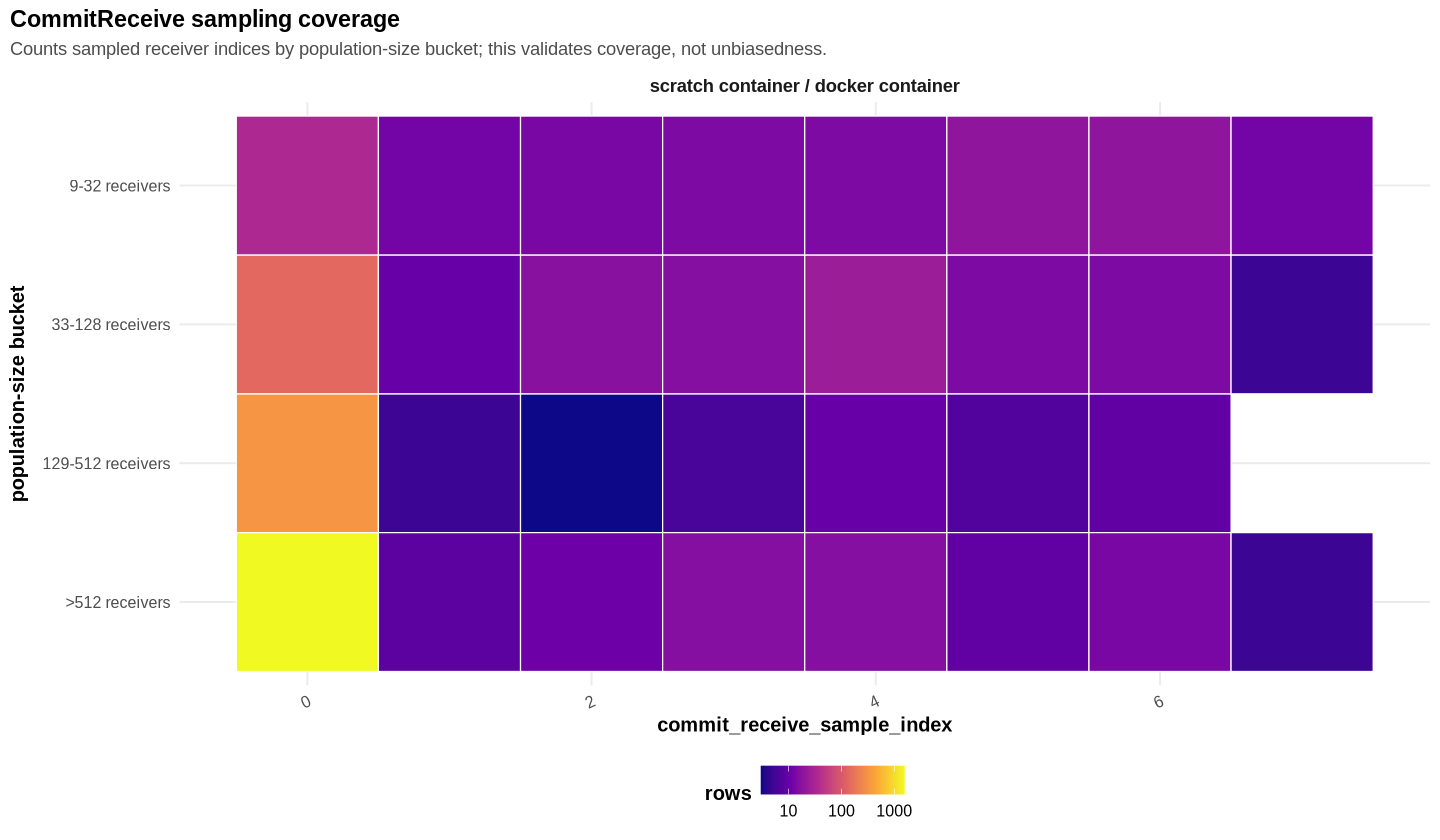


## plot_commit_receive_gam_surface


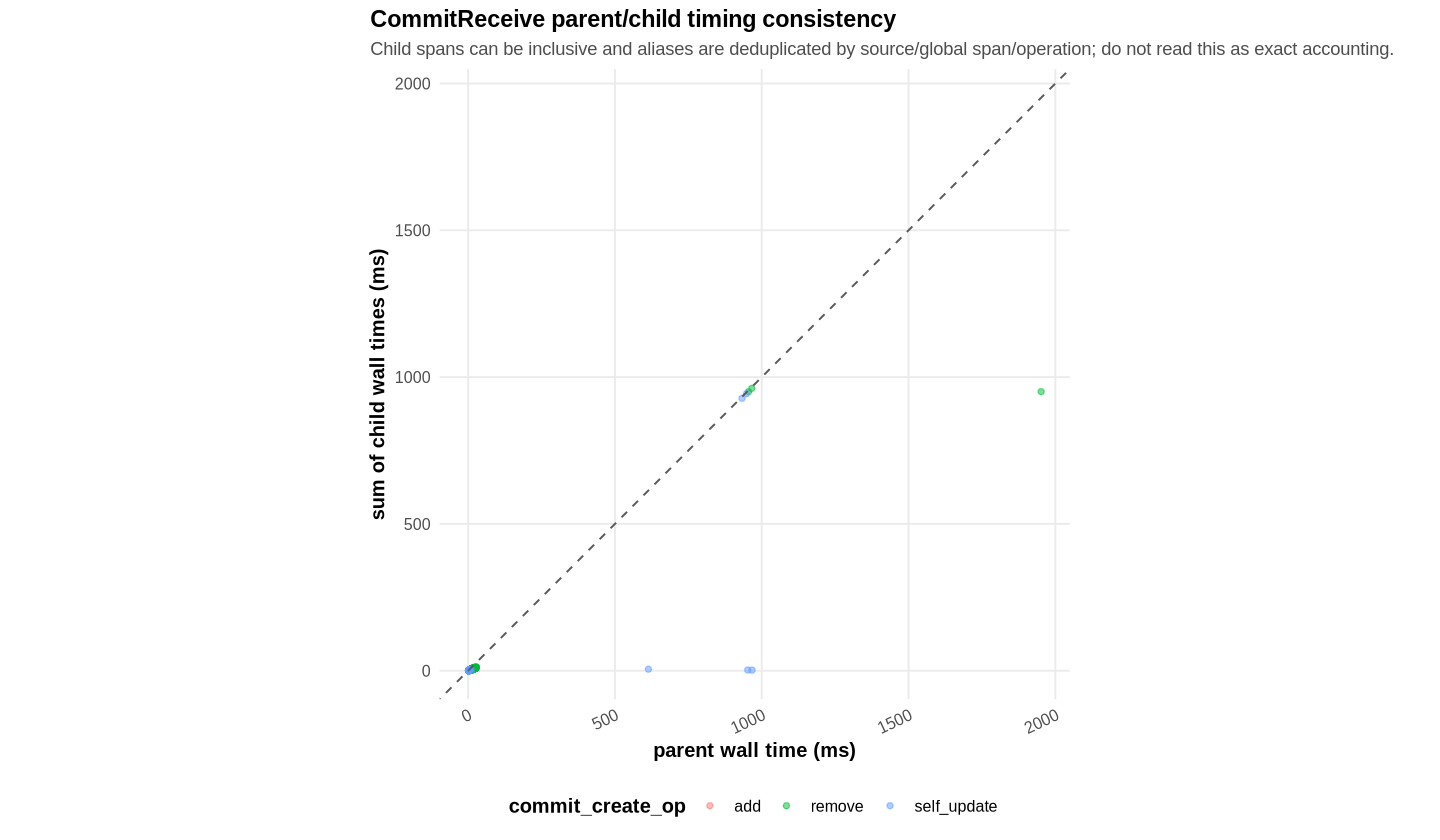

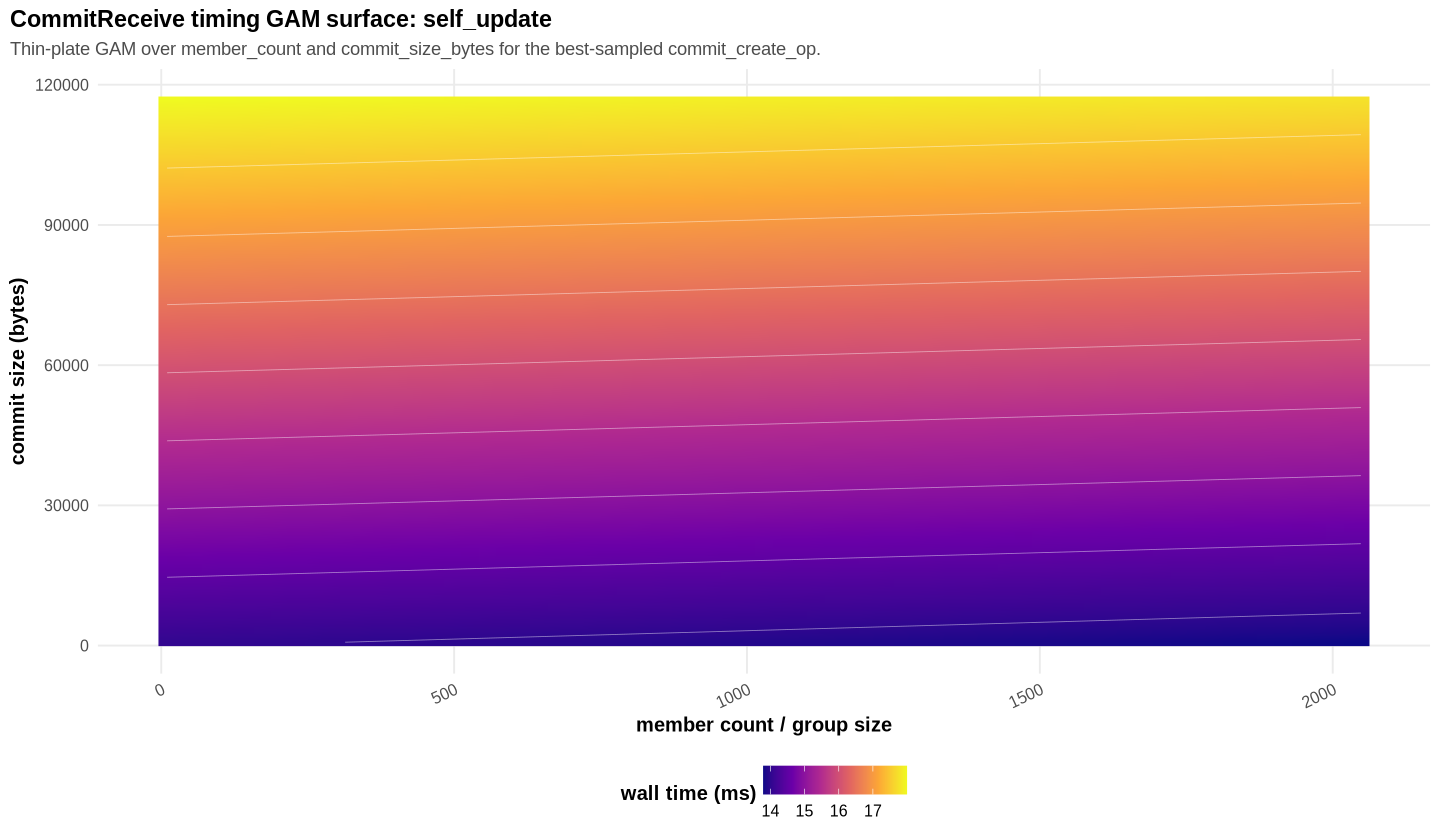

In [14]:
for (name in c(
  "plot_commit_receive_wall_by_member_count",
  "plot_commit_receive_wall_by_commit_size",
  "plot_commit_receive_child_decomposition",
  "plot_commit_receive_receiver_position",
  "plot_commit_receive_sampling_coverage",
  "plot_commit_receive_parent_child_consistency",
  "plot_commit_receive_gam_surface"
)) show_v5_plot(name)

## J. Resources / IoT


## plot_resource_alloc_by_operation_device



## plot_resource_rss_by_operation_device


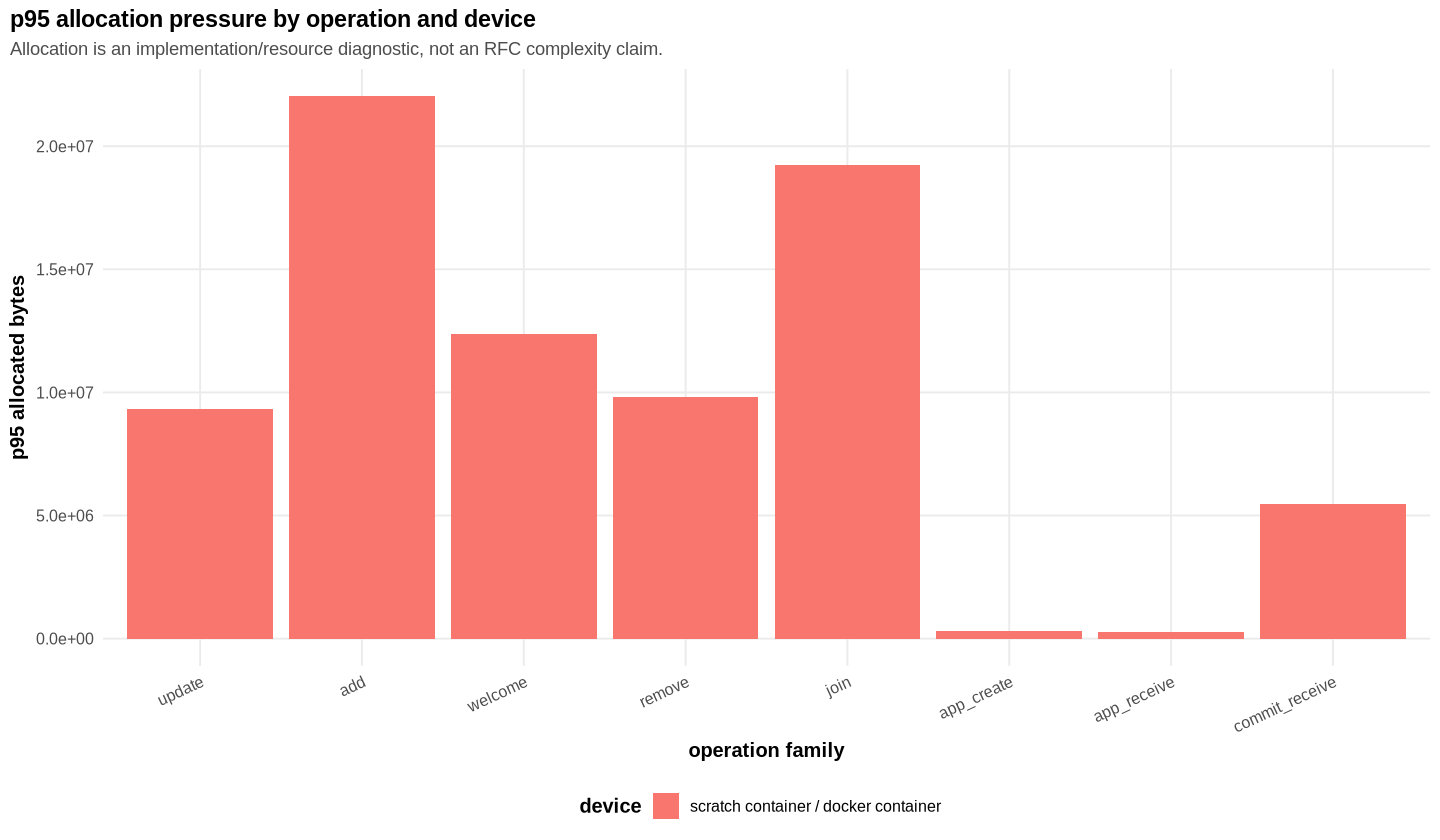


## plot_resource_cpu_by_operation_device


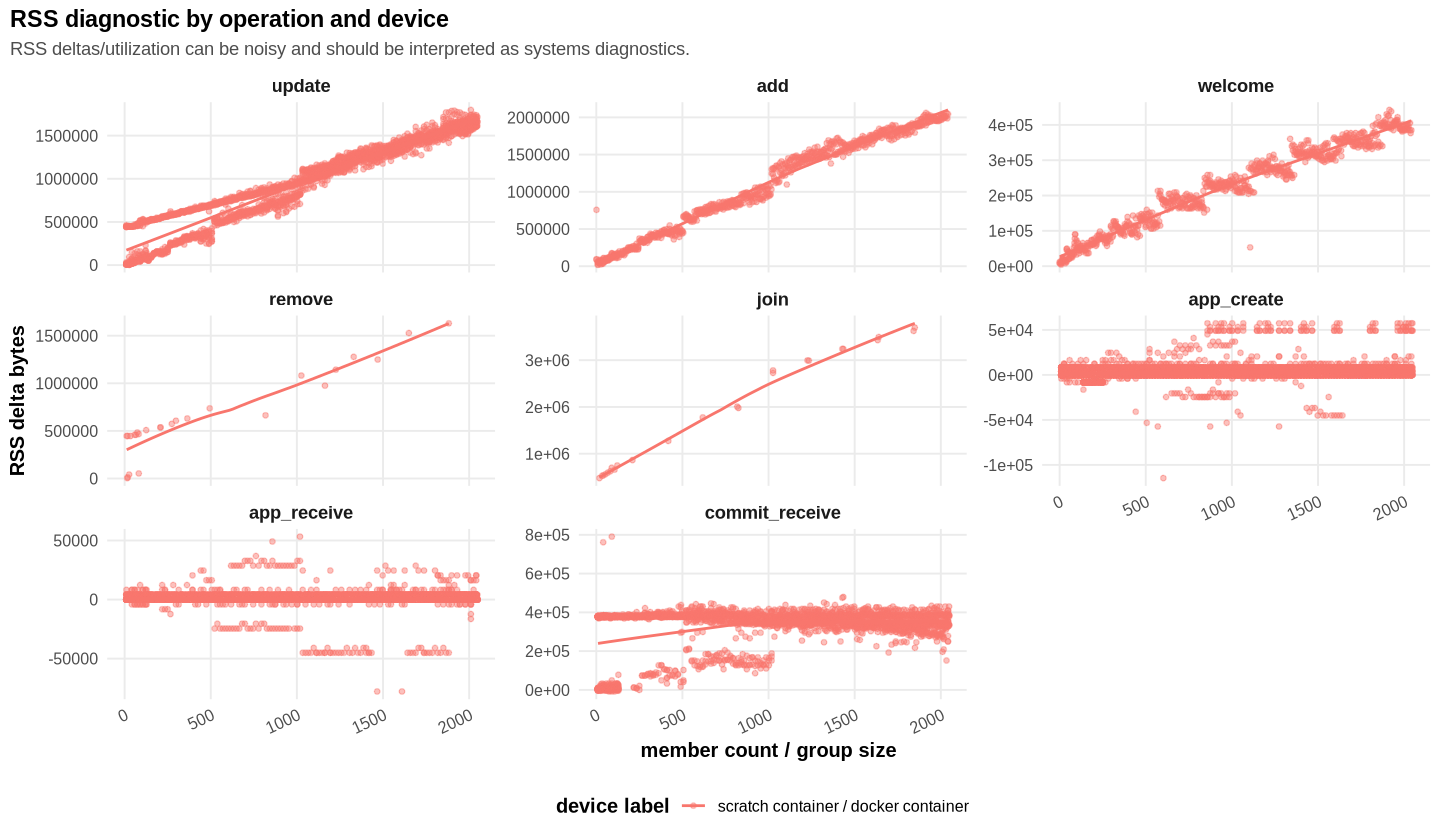


## plot_resource_throttling


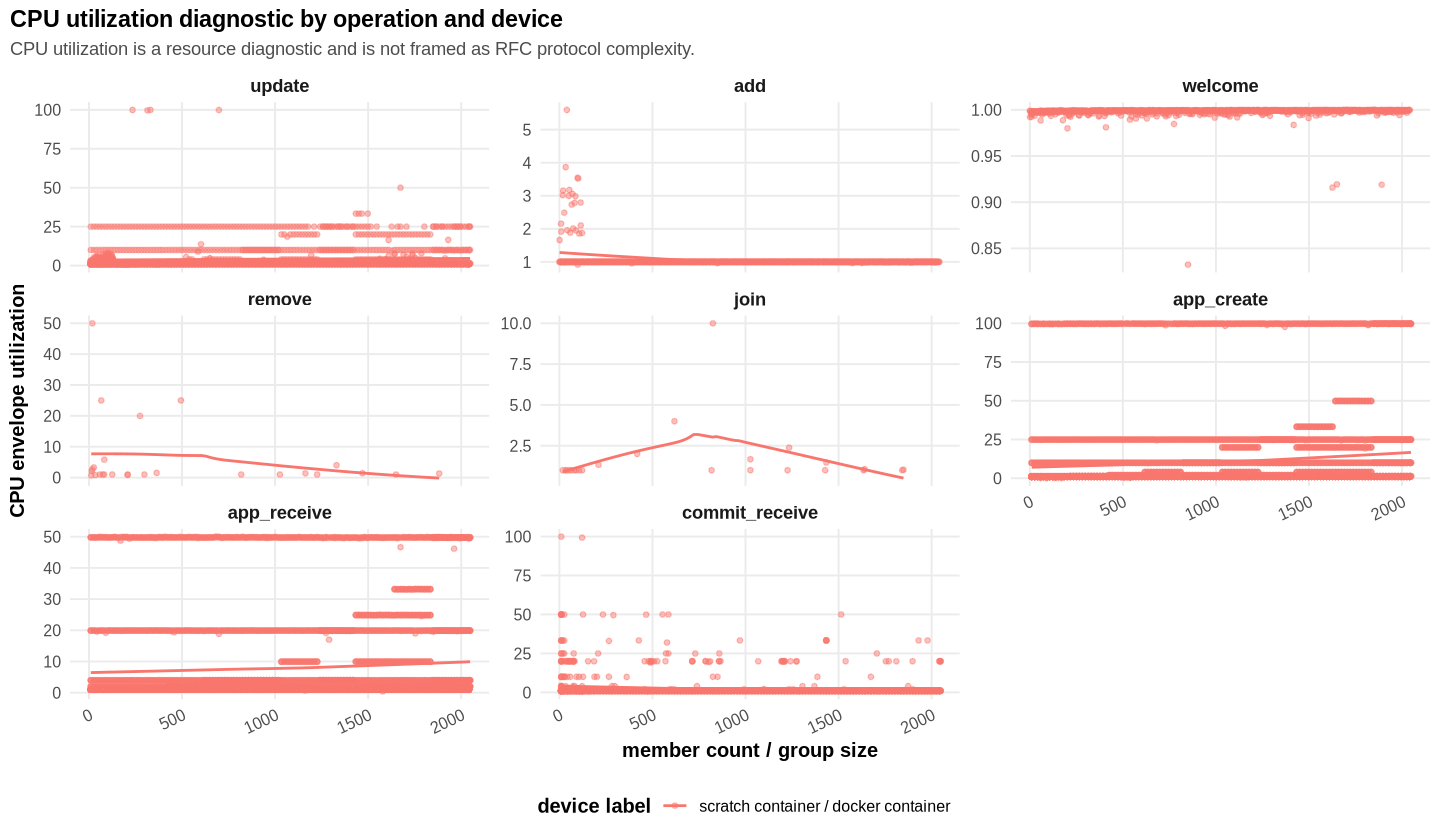


## plot_iot_feasibility_frontier
Skipped: no external-device parent rows

## plot_device_ranking_by_operation


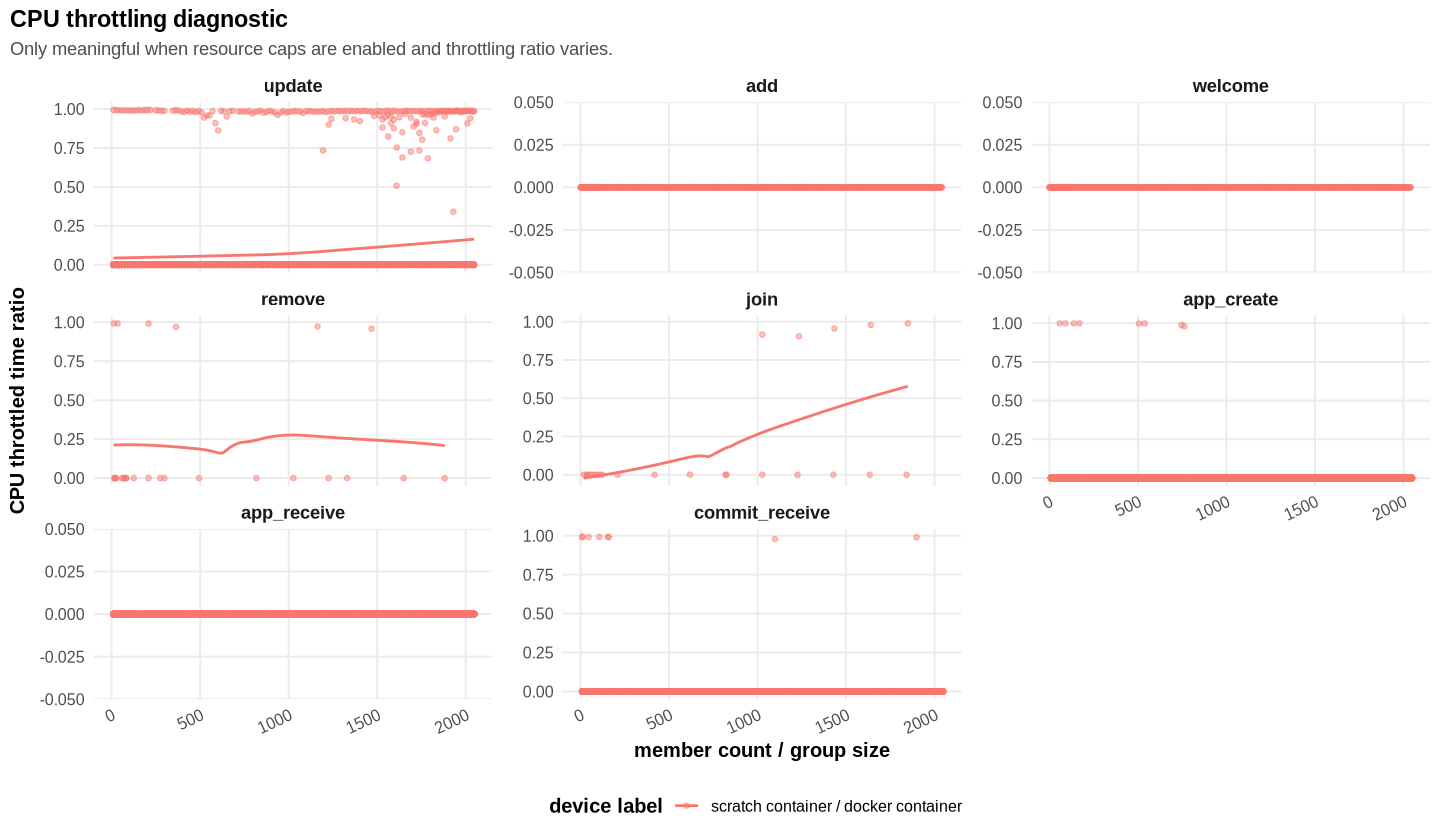

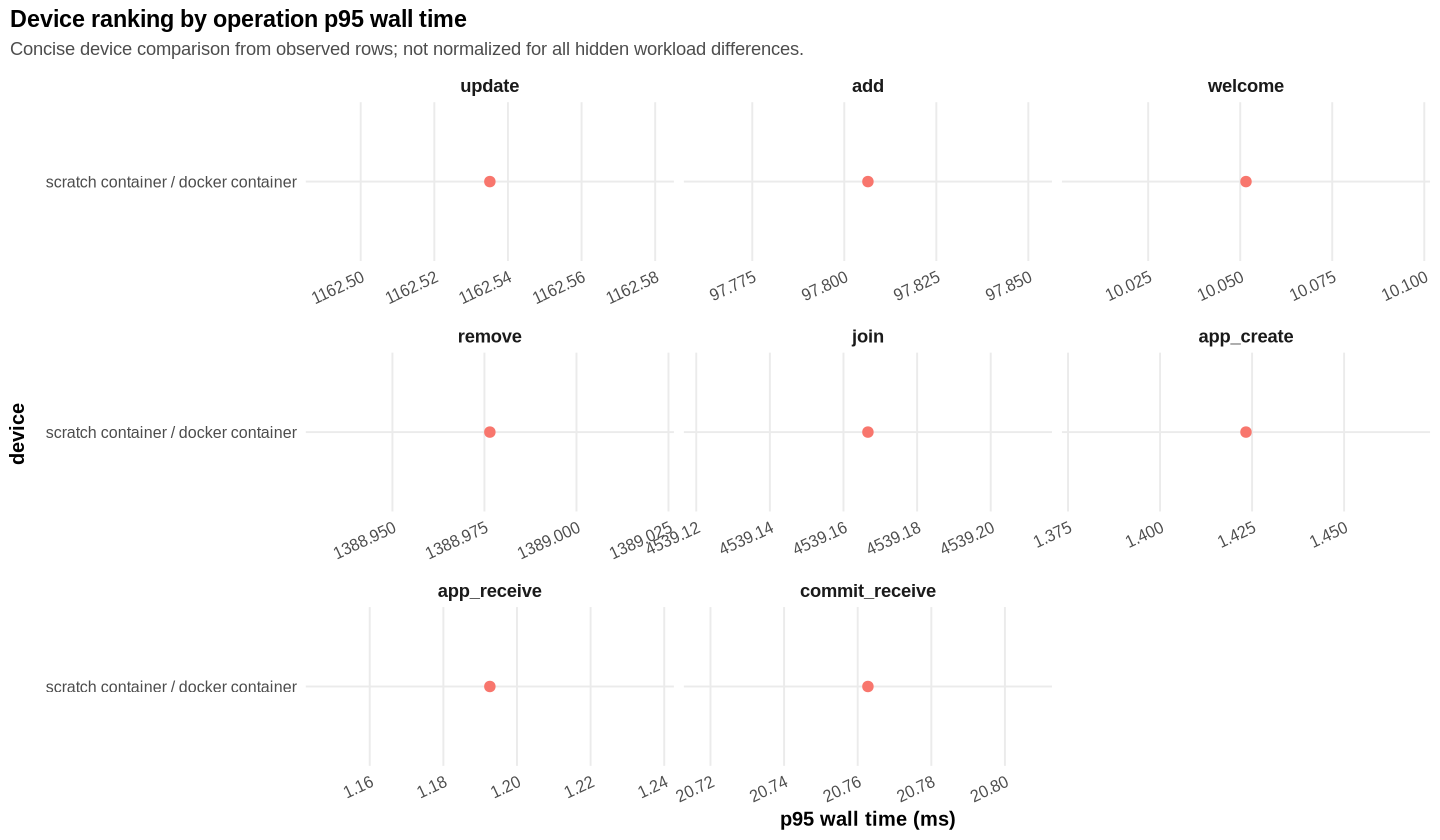

In [15]:
for (name in c(
  "plot_resource_alloc_by_operation_device",
  "plot_resource_rss_by_operation_device",
  "plot_resource_cpu_by_operation_device",
  "plot_resource_throttling",
  "plot_iot_feasibility_frontier",
  "plot_device_ranking_by_operation"
)) show_v5_plot(name)

## K. Summary Dashboard-style Views


## plot_operation_p95_overview



## plot_missingness_heatmap


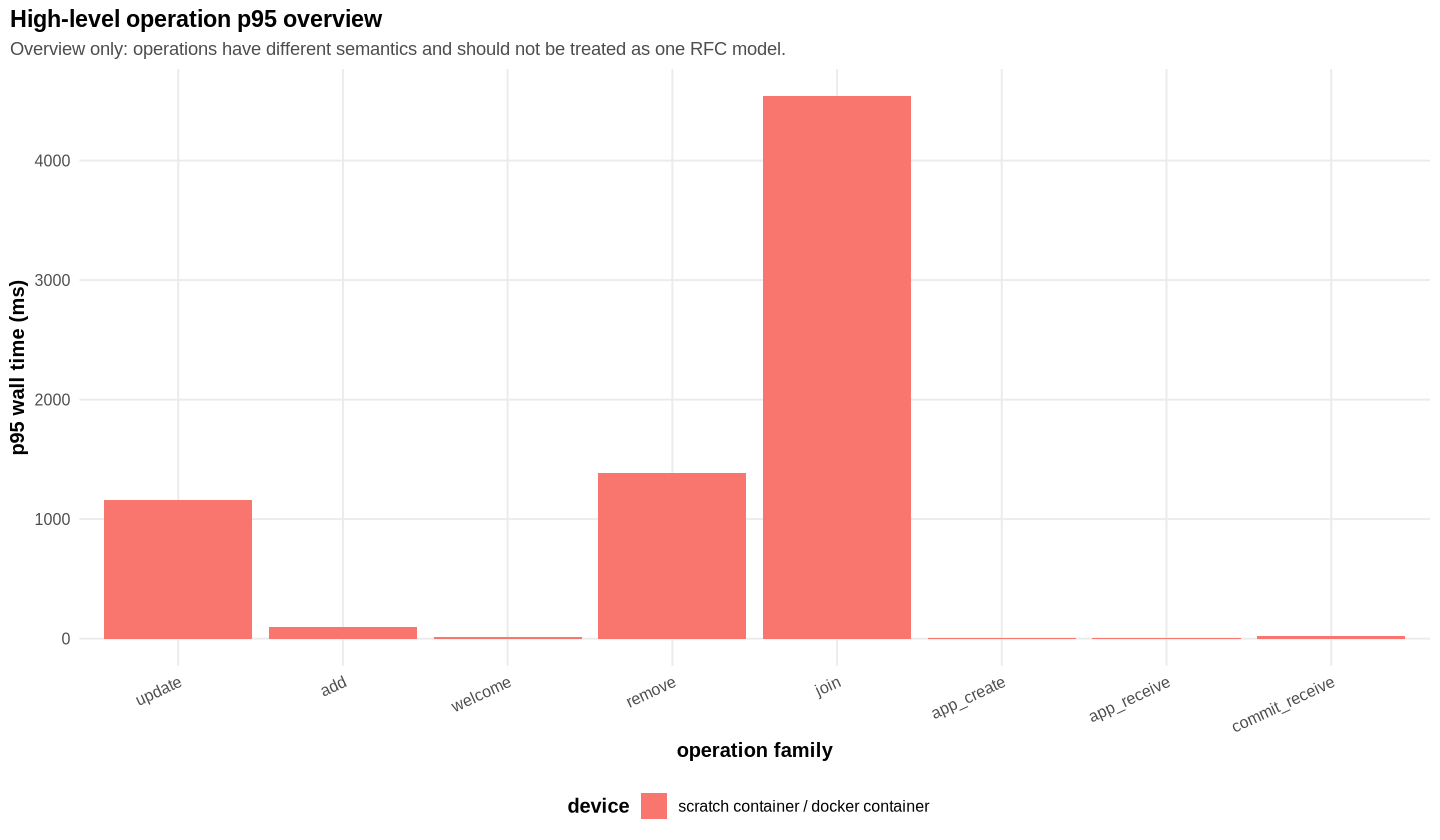

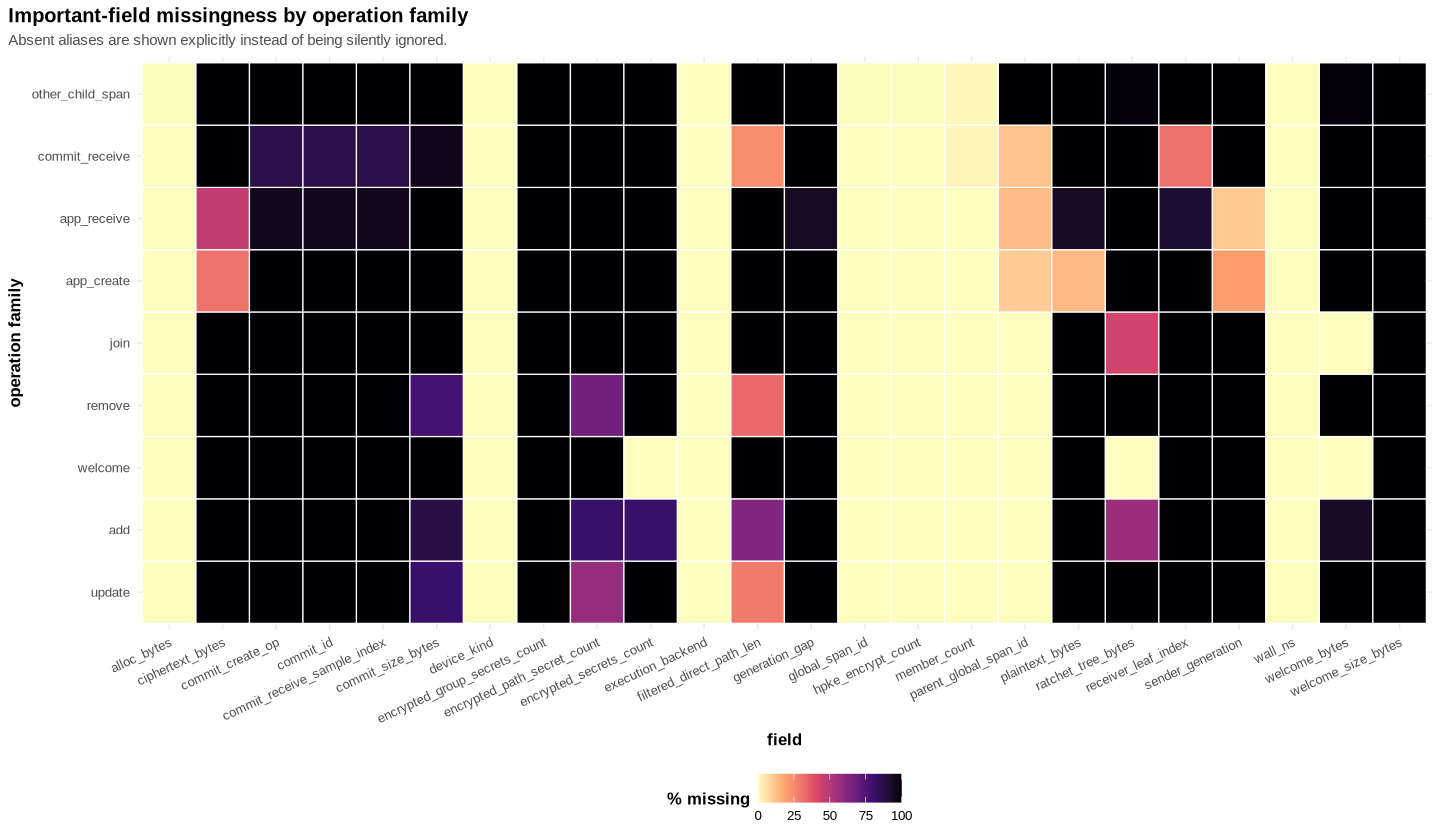

In [16]:
for (name in c(
  "plot_operation_p95_overview",
  "plot_missingness_heatmap"
)) show_v5_plot(name)

## Plot Files Written

In [17]:
table_paths <- write_openmls_v5_tables(openmls_v5_df, out_dir)
plot_result <- run_all_openmls_v5_plots(openmls_v5_df, out_dir)
plot_result$created
cat("Plot directory: ", file.path(out_dir, "plots"), "\n", sep = "")
cat("Table directory: ", file.path(out_dir, "tables"), "\n", sep = "")

[openmls-v5] Rendering plot_device_operation_coverage



[openmls-v5] Wrote analysis_output/openmls_v5/plots/plot_device_operation_coverage.png



[openmls-v5] Rendering plot_max_group_size_by_device_operation



[openmls-v5] Wrote analysis_output/openmls_v5/plots/plot_max_group_size_by_device_operation.png



[openmls-v5] Rendering plot_device_slowdown_vs_container



...

[openmls-v5] Rendering plot_missingness_heatmap



[openmls-v5] Wrote analysis_output/openmls_v5/plots/plot_missingness_heatmap.png



plot_name,filename,path
<chr>,<chr>,<chr>
plot_device_operation_coverage,plot_device_operation_coverage.png,analysis_output/openmls_v5/plots/plot_device_operation_coverage.png
plot_max_group_size_by_device_operation,plot_max_group_size_by_device_operation.png,analysis_output/openmls_v5/plots/plot_max_group_size_by_device_operation.png
plot_update_direct_path_scaling,plot_update_direct_path_scaling.png,analysis_output/openmls_v5/plots/plot_update_direct_path_scaling.png
plot_update_hpke_identity,plot_update_hpke_identity.png,analysis_output/openmls_v5/plots/plot_update_hpke_identity.png
plot_update_path_nodes_identity,plot_update_path_nodes_identity.png,analysis_output/openmls_v5/plots/plot_update_path_nodes_identity.png
plot_welcome_size_by_recipient_count,plot_welcome_size_by_recipient_count.png,analysis_output/openmls_v5/plots/plot_welcome_size_by_recipient_count.png
plot_ratchet_tree_bytes_by_tree_size,plot_ratchet_tree_bytes_by_tree_size.png,analysis_output/openmls_v5/plots/plot_ratchet_tree_bytes_by_tree_size.png
plot_ciphertext_vs_plaintext,plot_ciphertext_vs_plaintext.png,analysis_output/openmls_v5/plots/plot_ciphertext_vs_plaintext.png
plot_update_wall_time_loess,plot_update_wall_time_loess.png,analysis_output/openmls_v5/plots/plot_update_wall_time_loess.png


Plot directory: analysis_output/openmls_v5/plots


Table directory: analysis_output/openmls_v5/tables


## Skipped Plots And Reasons

In [18]:
plot_result$skipped

plot_name,filename,reason
<chr>,<chr>,<chr>
plot_device_slowdown_vs_container,plot_device_slowdown_vs_container.png,requires both container baseline rows and external-device rows
plot_remove_truncation_duration,plot_remove_truncation_duration.png,remove rows contain only one truncation state; boxplot would imply unsupported comparison
plot_join_delivery_mode_boxplot,plot_join_delivery_mode_boxplot.png,only one ratchet_tree_delivery_mode is present; delivery-mode comparison skipped
plot_join_gam_surface,plot_join_gam_surface.png,"JoinFromWelcome timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors"
plot_app_create_gam_surface,plot_app_create_gam_surface.png,"ApplicationMessageCreate timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors"
plot_app_receive_gam_surface,plot_app_receive_gam_surface.png,"ApplicationMessageReceive timing GAM surface needs at least 80 rows, 30 unique predictor pairs, and varied predictors"
plot_iot_feasibility_frontier,plot_iot_feasibility_frontier.png,no external-device parent rows


## Final Caveats And Next Steps

In [19]:
cat("Caveats:\n")
cat("- Current runs are useful for exploratory OpenMLS operation-level analysis.\n")
cat("- Do not make final thesis claims from partial/smoke-only data or stale benchmark context fields.\n")
cat("- CommitReceive is included and should stay separated by commit_create_op.\n")
cat("- External-device rows are included where present and kept separate from container rows.\n")
cat("- Rerun this notebook after larger benchmark runs; the reader batches files and CSV row chunks.\n")

Caveats:


- Current runs are useful for exploratory OpenMLS operation-level analysis.


- Do not make final thesis claims from partial/smoke-only data or stale benchmark context fields.


- CommitReceive is included and should stay separated by commit_create_op.


- External-device rows are included where present and kept separate from container rows.


- Rerun this notebook after larger benchmark runs; the reader batches files and CSV row chunks.
